# 🎬 Recommender Systems — Popularity, Content, Collaborative Filtering, Matrix Factorization, and Ranking Metrics

> **What you'll learn:** how recommenders turn a sparse user–item matrix into a ranked list for every user — explicit vs implicit feedback, the long tail and cold start, evaluation done right (temporal splits, precision/recall/MAP/NDCG@k, hit rate, MRR, coverage, novelty, diversity), the baselines that are hard to beat, content-based TF-IDF profiles, user- and item-based kNN, matrix factorization with biases, implicit-feedback ALS and BPR with the `implicit` library, two-stage retrieval + learning-to-rank, and re-ranking for diversity — plus ranking metrics, SGD matrix factorization, and the ALS update built from scratch and checked against scikit-learn and `implicit`.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Model Interpretability](18_Model_Interpretability_SHAP_LIME.ipynb) (the previous notebook in this series) · [K-Nearest Neighbors](05_K_Nearest_Neighbors.ipynb) (similarity and neighbours) · [Dimensionality Reduction](14_Dimensionality_Reduction_PCA_tSNE_UMAP.ipynb) (SVD and low-rank structure) |
| **Tested with** | Python 3.12 · implicit 0.7 · scikit-learn 1.9 · lightgbm 4.7 · scipy 1.18 · numpy 2.5 · pandas 3.0 |
| **Interview relevance** | ⭐⭐⭐ Very high — "design a recommender", "explicit vs implicit feedback", "why NDCG and not RMSE?", "item-based vs user-based CF", "explain matrix factorization / ALS", "how do you handle cold start?", "why did offline gains not show up in the A/B test?" |

## 🤔 What Is a Recommender System?

Think of a good bookshop owner. They remember what you bought, notice that people who liked the same books as you also loved a new title, and put *that* book in your hands — not the bestseller you've already read. A **recommender system** does this automatically for millions of people and items.

| Term | Plain English |
|---|---|
| **User / item** | the person, and the thing recommended (movie, song, product, post) |
| **Interaction** | any recorded contact: a rating, a click, a play, a purchase |
| **Explicit feedback** | the user tells you how much they liked it (a 1–5 star rating) |
| **Implicit feedback** | you infer interest from behaviour (watched, clicked, bought) — plentiful but noisy, and "no interaction" doesn't mean "dislike" |
| **User–item matrix** | one row per user, one column per item, interactions in the cells — almost all cells are empty |
| **Top-k recommendation** | the ranked list of the *k* items we show (k = 10 here) |
| **Collaborative filtering (CF)** | recommend using *other users'* behaviour ("people like you liked…") |
| **Content-based** | recommend using *item attributes* ("more comedies, since you like comedies") |
| **Cold start** | a new user or item with no interactions yet |

The core task is **ranking**: for each user, order the items they haven't seen so the ones they'll engage with come first.

## 🎯 Why It Matters

- **It's where much of the money is.** Feeds, streaming home pages, "customers also bought", ads, playlists, job and dating matches are all recommenders; a small ranking improvement is worth millions at scale.
- **It's a distinct kind of ML.** The data is a sparse matrix, the output is a ranked list, the labels are implicit and biased by what you showed before, and offline metrics only loosely predict online A/B results. Engineers who understand those differences are rare.
- **Classical methods still matter.** Popularity, item-kNN, and matrix factorization (ALS) remain strong baselines and candidate generators behind deep two-tower and transformer rankers.
- **In interviews** it appears as a system-design round ("design YouTube/Netflix/Amazon recommendations" — see [ML System Design, case study 16](../15_Interview_Prep/03_ML_System_Design.ipynb)) and as modelling questions: *"explicit vs implicit feedback?"*, *"NDCG vs RMSE?"*, *"how does ALS work and why is it parallel?"*, *"item-based vs user-based CF?"*, *"how do you split data without leaking the future?"*, *"how do you fix cold start and popularity bias?"* This notebook is the modelling side; every answer comes with an experiment on real MovieLens data.

## 🃏 Algorithm Card

This notebook covers **approaches**, so the card has one column per approach (same rows as every notebook in the series).

| | Popularity | Content-based (TF-IDF) | Item-kNN CF | Matrix factorization / ALS | Learning-to-rank hybrid |
|---|---|---|---|---|---|
| **Learning type** | non-personalized counting | supervised-by-profile, per user | memory-based collaborative filtering | model-based CF (latent factors); explicit (SGD) or implicit (weighted ALS, BPR) | supervised ranking over candidates |
| **Tasks** | top-k for everyone; cold-start fallback | top-k, "similar items", item cold start | top-k, "because you watched X" | top-k, rating prediction, embeddings for retrieval | final ranking in a two-stage system |
| **Model / objective** | score = interaction count (optionally recent/decayed) | score = cosine(user profile, item TF-IDF vector) | $\hat s_{ui}=\sum_{j\in I_u} \text{sim}(i,j)$ over top neighbours, with shrinkage | explicit: $\min \sum (r_{ui}-\mu-b_u-b_i-p_u^\top q_i)^2+\lambda(\lVert p\rVert^2+\lVert q\rVert^2+b^2)$; implicit: $\min\sum_{u,i} c_{ui}(p_{ui}-x_u^\top y_i)^2+\lambda(\dots)$ | LambdaRank / pairwise loss on candidate features, optimizing NDCG |
| **Key hyperparameters** | time window | tokens used, TF-IDF weighting, profile weighting | neighbours k (20–200), similarity (cosine / adjusted / Pearson), shrinkage β (0–100) | factors (16–256), regularization λ (0.01–1), iterations (10–50), α confidence (1–100), learning rate (SGD) | candidates per user (50–500), features, trees, `label_gain` |
| **Needs feature scaling?** | no | TF-IDF normalizes | centring ratings (adjusted cosine) helps | ratings centred by biases | no (tree ranker) |
| **Handles missing values / categoricals?** | n/a | items need metadata; categorical tags → tokens | missing = no interaction | missing = unobserved (explicit: ignored; implicit: weak negative) | tree ranker handles missing features |
| **Training & prediction complexity** | $O(\text{nnz})$ / $O(1)$ | $O(\text{items}\cdot\text{vocab})$ / one sparse dot product per item | similarity $O(\sum_u n_u^2)$ / sum over the user's history | ALS: $O(\text{nnz}\,k^2 + (U+I)k^3)$ per iteration; SGD: $O(\text{nnz}\,k)$ per epoch / $O(Ik)$ per user | candidates × features × trees |
| **Interpretability** | total | high ("you like Comedy") | high ("because you watched X") | low (latent dimensions) | medium (feature importance/SHAP) |
| **Strengths** | trivial, robust, strong baseline | no cold start for items, transparent | simple, strong, explainable, easy updates | captures latent tastes, compact embeddings, scales (ALS parallel) | combines all signals, directly optimizes ranking |
| **Weaknesses** | no personalization, popularity bias | over-specialization, needs good metadata | sparse overlap, memory for similarities, popularity-biased | cold start, less explainable, tuning | needs labels, two systems to maintain, leakage-prone |
| **Use it when** | new users, fallback, sanity baseline | items have rich metadata or are new | moderate catalogs; "similar items" widgets | large implicit datasets; embedding retrieval | you have several candidate sources and rich features |
| **Avoid it when** | personalization is the product | metadata is poor | extreme sparsity or huge catalogs without pruning | pure cold-start scenarios | you lack clean time-split training data |
| **Best libraries** | pandas | scikit-learn `TfidfVectorizer` | NumPy/SciPy sparse, `implicit.nearest_neighbours` | `implicit` (ALS, BPR), Spark MLlib ALS, `surprise` (explicit) | LightGBM `LGBMRanker`, XGBoost `rank:ndcg` |

## ✅ By the End You Can

- [ ] Describe explicit vs implicit feedback, measure sparsity, the long tail, popularity bias, and cold start on real data
- [ ] Split interaction data by time without leaking the future, and compute precision@k, recall@k, MAP@k, NDCG@k, hit rate, MRR, coverage, novelty, and diversity
- [ ] Build and compare popularity, bias, content-based, user-/item-kNN, SVD, SGD matrix factorization, implicit ALS, and BPR recommenders
- [ ] Explain two-stage systems (candidate generation → learning-to-rank) and re-rank for diversity with MMR
- [ ] Implement ranking metrics, matrix factorization with biases, and the implicit-ALS update from scratch and match scikit-learn and `implicit`

## 📋 Table of Contents

1. [The User–Item Matrix: Explicit vs Implicit Feedback](#1.-The-User–Item-Matrix:-Explicit-vs-Implicit-Feedback-🟢)
2. [The Long Tail, Popularity Bias, and Cold Start](#2.-The-Long-Tail,-Popularity-Bias,-and-Cold-Start-🟢)
3. [Ranking Metrics: Precision, Recall, MAP, NDCG, Hit Rate, MRR](#3.-Ranking-Metrics:-Precision,-Recall,-MAP,-NDCG,-Hit-Rate,-MRR-🟡)
4. [Splitting Without Leaking the Future](#4.-Splitting-Without-Leaking-the-Future-🟡)
5. [Baselines: Most-Popular and the Bias Model](#5.-Baselines:-Most-Popular-and-the-Bias-Model-🟢)
6. [Content-Based Filtering With TF-IDF](#6.-Content-Based-Filtering-With-TF-IDF-🟡)
7. [Neighbourhood CF: User-Based vs Item-Based kNN](#7.-Neighbourhood-CF:-User-Based-vs-Item-Based-kNN-🟡)
8. [Matrix Factorization: Latent Factors and SVD](#8.-Matrix-Factorization:-Latent-Factors-and-SVD-🔴)
9. [Implicit Feedback: Weighted ALS and BPR](#9.-Implicit-Feedback:-Weighted-ALS-and-BPR-🔴)
10. [Two-Stage Systems: Candidates, Then Learning-to-Rank](#10.-Two-Stage-Systems:-Candidates,-Then-Learning-to-Rank-🔴)
11. [Beyond Accuracy: Popularity Bias, Diversity, and Feedback Loops](#11.-Beyond-Accuracy:-Popularity-Bias,-Diversity,-and-Feedback-Loops-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project (the head-to-head)](#🚀-Mini-Project:-MovieLens-Recommender-Shoot-Out) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**Data:** [MovieLens](https://grouplens.org/datasets/movielens/) `ml-latest-small` from GroupLens (University of Minnesota): 100,836 real ratings (0.5–5 stars) of 9,742 movies by 610 users, 1996–2018. The ~1 MB zip is downloaded once into `_outputs/movielens/` (git-ignored). The [usage licence in the README](https://files.grouplens.org/datasets/movielens/ml-latest-small-README.html) allows research and education use, requires acknowledging the dataset (F. Maxwell Harper and Joseph A. Konstan, 2015, *The MovieLens Datasets: History and Context*, ACM TiiS), and forbids redistribution without permission — so we never commit the files, we download them.

**Threads:** `implicit`'s ALS runs its own parallel loops; if NumPy's BLAS (e.g. OpenBLAS) also spawns threads they fight each other, and `implicit` warns you to set `OPENBLAS_NUM_THREADS=1`. We print which BLAS NumPy uses, limit BLAS to 1 thread inside `implicit` calls with `threadpoolctl`, and give `implicit` a modest `num_threads=4`.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "implicit>=0.7" "scikit-learn>=1.9" "lightgbm>=4.6" "numpy>=2.0" "pandas>=2.2" scipy matplotlib threadpoolctl

import importlib.metadata
import io
import itertools
import math
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

import implicit
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import sklearn
import threadpoolctl
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import normalize

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | SciPy {scipy.__version__} | scikit-learn {sklearn.__version__}")
print(f"implicit {implicit.__version__} | lightgbm {lgb.__version__}")
blas = [(info["internal_api"], info["num_threads"]) for info in threadpoolctl.threadpool_info() if info["user_api"] == "blas"]
print(f"BLAS thread pools seen by threadpoolctl: {blas}" if blas else
      "threadpoolctl sees no OpenBLAS/MKL thread pool (e.g. NumPy built on Apple Accelerate) → implicit has nothing to warn about")

SEED = 42
K = 10                                          # we evaluate top-10 lists throughout
N_THREADS = 4
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")                   # files we write go here (ignored by git)
ML_DIR = OUTPUT_DIR / "movielens"
ML_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, atol=atol, rtol=1e-5)
    except (TypeError, ValueError):
        ok = np.array_equal(np.asarray(got), np.asarray(expected)) if isinstance(expected, (list, np.ndarray)) else got == expected
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | pandas 3.0.5 | SciPy 1.18.1 | scikit-learn 1.9.1
implicit 0.7.3 | lightgbm 4.7.0
threadpoolctl sees no OpenBLAS/MKL thread pool (e.g. NumPy built on Apple Accelerate) → implicit has nothing to warn about


## 1. The User–Item Matrix: Explicit vs Implicit Feedback 🟢

MovieLens ratings are **explicit** feedback: each row says *user u gave movie i r stars at time t*. The same log can be read as **implicit** feedback — *user u watched (and bothered to rate) movie i* — which is how most real products look: clicks, plays, and purchases, with no "dislike" signal for items never touched.

```
                Toy Story  Heat  Jumanji  Casino  ...  (9,742 movies)
  user 1     [    4.0      4.0     .        .     ... ]
  user 2     [     .        .      .       5.0    ... ]      "." = never rated
  ...                                                         (≈98% of cells!)
  user 610   [    3.5       .     2.5       .     ... ]
```

In [2]:
ratings_path = ML_DIR / "ml-latest-small" / "ratings.csv"
if not ratings_path.exists():
    ML_DIR.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(ML_URL, timeout=60) as response:
        zipfile.ZipFile(io.BytesIO(response.read())).extractall(ML_DIR)
    print(f"downloaded and extracted {ML_URL} → {ML_DIR}")
ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(ML_DIR / "ml-latest-small" / "movies.csv")
ratings["time"] = pd.to_datetime(ratings["timestamp"], unit="s")
print(ratings.head(3).to_string(index=False))

n_users, n_items_rated = ratings["userId"].nunique(), ratings["movieId"].nunique()
density = len(ratings) / (n_users * n_items_rated)
print(f"\n{len(ratings):,} ratings | {n_users} users | {n_items_rated:,} rated movies (of {len(movies):,} in movies.csv) | "
      f"{ratings['time'].min():%Y-%m} → {ratings['time'].max():%Y-%m}")
print(f"density = {len(ratings):,} / ({n_users} × {n_items_rated:,}) = {density:.2%} → {1 - density:.2%} of the matrix is empty")
per_user = ratings.groupby("userId").size()
print(f"ratings per user: min {per_user.min()}, median {per_user.median():.0f}, max {per_user.max()}")

 userId  movieId  rating  timestamp                time
      1        1     4.0  964982703 2000-07-30 18:45:03
      1        3     4.0  964981247 2000-07-30 18:20:47
      1        6     4.0  964982224 2000-07-30 18:37:04

100,836 ratings | 610 users | 9,724 rated movies (of 9,742 in movies.csv) | 1996-03 → 2018-09
density = 100,836 / (610 × 9,724) = 1.70% → 98.30% of the matrix is empty
ratings per user: min 20, median 70, max 2698


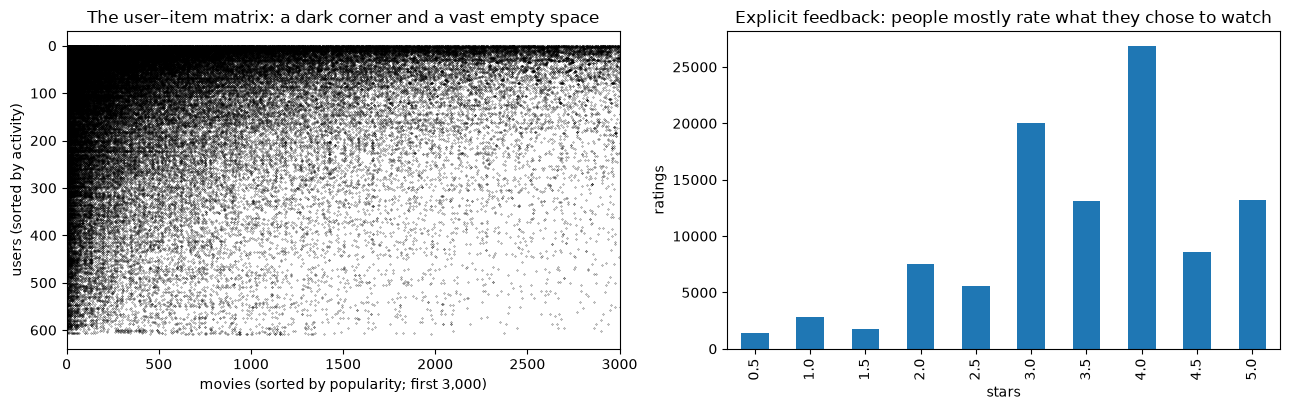

mean rating 3.50; share of ratings ≥ 4: 48% — ratings are missing *not at random*: people watch (and rate) what they expect to like


In [3]:
user_order = per_user.sort_values(ascending=False).index
item_counts = ratings["movieId"].value_counts()
item_order = item_counts.index
u_pos = pd.Series(np.arange(len(user_order)), index=user_order)
i_pos = pd.Series(np.arange(len(item_order)), index=item_order)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(i_pos[ratings["movieId"]].to_numpy(), u_pos[ratings["userId"]].to_numpy(), s=0.05, color="k")
axes[0].set(xlim=(0, 3000), xlabel="movies (sorted by popularity; first 3,000)", ylabel="users (sorted by activity)",
            title="The user–item matrix: a dark corner and a vast empty space")
axes[0].invert_yaxis()
ratings["rating"].value_counts().sort_index().plot.bar(ax=axes[1], color="#1f77b4")
axes[1].set(xlabel="stars", ylabel="ratings", title="Explicit feedback: people mostly rate what they chose to watch")
plt.tight_layout()
plt.show()
print(f"mean rating {ratings['rating'].mean():.2f}; share of ratings ≥ 4: {np.mean(ratings['rating'] >= 4):.0%} "
      "— ratings are missing *not at random*: people watch (and rate) what they expect to like")

### ✍️ Your Turn

Suppose a shop has 2,000 customers, 50,000 products, and 300,000 purchases (each customer–product pair counted once). What is the density of its customer–product matrix? Store the fraction in `shop_density`.

In [4]:
shop_density = None  # TODO: your code here
check("shop_density", shop_density, 300_000 / (2_000 * 50_000), hint="interactions / (users × items)")

⏳ shop_density: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
shop_density = 300_000 / (2_000 * 50_000)       # 0.003 = 0.3% — even sparser than MovieLens
check("shop_density", shop_density, 300_000 / (2_000 * 50_000))
```
A dense float matrix of that size would need 800 MB; a sparse CSR matrix stores only the 300,000 non-zeros (≈ 3.6 MB).
</details>

> 💡 **Interview angle:** "Explicit vs implicit feedback — what changes?" — explicit ratings have both likes and dislikes but are scarce and biased toward items people chose; implicit signals are abundant but only positive and noisy, and a missing interaction may mean "didn't know about it" rather than "dislike". Implicit models therefore treat unobserved items as weak negatives with low confidence (weighted ALS) or learn pairwise preferences (BPR), and are evaluated with ranking metrics rather than RMSE.

## 2. The Long Tail, Popularity Bias, and Cold Start 🟢

A few blockbusters get most of the interactions; thousands of movies have one or two. That **long tail** shapes everything: CF works best in the "head", popular items dominate naive recommendations (**popularity bias**), and tail items and new users have too little data (**cold start**).

top 1% of movies (98) get 16% of ratings; top 20% (1945) get 77%
movies with exactly 1 rating: 35%; with fewer than 5: 62%
most rated: Forrest Gump (1994), Shawshank Redemption, The (1994), Pulp Fiction (1994), Silence of the Lambs, The (1991), Matrix, The (1999)


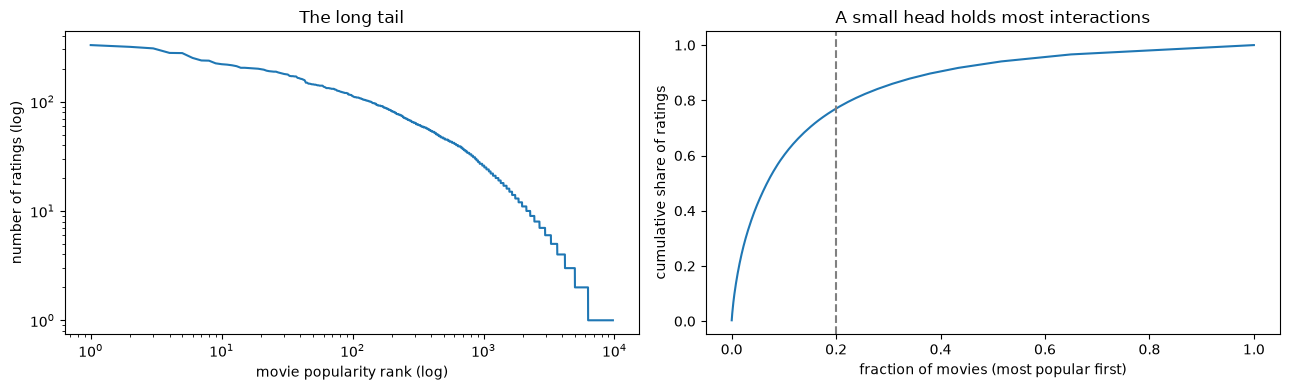

In [5]:
counts_sorted = item_counts.to_numpy()
cum_share = np.cumsum(counts_sorted) / counts_sorted.sum()
top_1pct = int(np.ceil(0.01 * len(counts_sorted)))
top_20pct = int(np.ceil(0.20 * len(counts_sorted)))
print(f"top 1% of movies ({top_1pct}) get {cum_share[top_1pct - 1]:.0%} of ratings; top 20% ({top_20pct}) get {cum_share[top_20pct - 1]:.0%}")
print(f"movies with exactly 1 rating: {np.mean(counts_sorted == 1):.0%}; with fewer than 5: {np.mean(counts_sorted < 5):.0%}")
print("most rated:", ", ".join(movies.set_index("movieId").loc[item_counts.index[:5], "title"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, len(counts_sorted) + 1), counts_sorted)
axes[0].set(xscale="log", yscale="log", xlabel="movie popularity rank (log)", ylabel="number of ratings (log)", title="The long tail")
axes[1].plot(np.arange(1, len(counts_sorted) + 1) / len(counts_sorted), cum_share)
axes[1].axvline(0.2, color="gray", ls="--")
axes[1].set(xlabel="fraction of movies (most popular first)", ylabel="cumulative share of ratings", title="A small head holds most interactions")
plt.tight_layout()
plt.show()

**Cold start comes in three flavours:** a *new user* (no history → fall back to popularity, onboarding questions, or context such as location and device), a *new item* (no interactions → content-based features, or exploration slots), and a *new system* (no data at all → editorial or content rules). We'll measure how many test movies are brand-new once we split the data in section 4.

### ✍️ Your Turn

What share of all ratings go to the **top 10%** most-rated movies? Store the fraction in `share_top10`.

In [6]:
share_top10 = None  # TODO: your code here
check("share_top10", share_top10, cum_share[int(np.ceil(0.10 * len(counts_sorted))) - 1], hint="Use cum_share at position ceil(0.10 × number of movies) − 1.")

⏳ share_top10: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_top10 = int(np.ceil(0.10 * len(counts_sorted)))
share_top10 = counts_sorted[:n_top10].sum() / counts_sorted.sum()
check("share_top10", share_top10, cum_share[int(np.ceil(0.10 * len(counts_sorted))) - 1])
```
</details>

> 💡 **Interview angle:** "How do you handle cold start?" — new users: popularity (possibly segmented by country/device/time), onboarding preference questions, session-based signals, then switch to CF as interactions arrive; new items: content/metadata embeddings, and reserved exploration traffic (bandits) to collect interactions; always track metrics separately for cold and warm segments.

## 3. Ranking Metrics: Precision, Recall, MAP, NDCG, Hit Rate, MRR 🟡

**Evaluation comes before models**, because the metric decides which model "wins". A recommender shows a **ranked list**; for each user we compare the top-*k* list with the set $R_u$ of held-out items the user actually interacted with ("relevant" items). With $\text{rel}_i = 1$ if the item at rank $i$ is relevant:

| Metric | Formula (per user, averaged over users) | Question it answers |
|---|---|---|
| **Precision@k** | $\frac{1}{k}\sum_{i\le k}\text{rel}_i$ | what share of the shown slots were good? |
| **Recall@k** | $\frac{1}{\lvert R_u\rvert}\sum_{i\le k}\text{rel}_i$ | what share of the good items did we show? |
| **Hit rate@k** | $\mathbb 1[\sum_{i\le k}\text{rel}_i>0]$ | did we show at least one? |
| **MRR@k** | $1/\text{rank of the first relevant item}$ (0 if none) | how far must the user scroll to the first hit? |
| **AP@k → MAP@k** | $\frac{1}{\min(k,\lvert R_u\rvert)}\sum_{i\le k}\text{Precision@}i\cdot\text{rel}_i$ | are hits concentrated at the top? |
| **NDCG@k** | $\frac{\text{DCG@k}}{\text{IDCG@k}}$, $\text{DCG@k}=\sum_{i\le k}\frac{\text{rel}_i}{\log_2(i+1)}$ | position-discounted gain vs the best possible list |

(MAP's normalizer varies between libraries — $\lvert R_u\rvert$ or $\min(k, \lvert R_u\rvert)$; always state which.) **Beyond accuracy:** *catalog coverage* = share of all items that appear in anyone's list; *novelty* = mean $-\log_2(\text{item popularity})$ (recommending the obvious is not novel); *diversity* = mean pairwise dissimilarity inside a list (here: 1 − cosine similarity of genres).

A hand-computed example: the list is `[A, B, C, D, E]` and the relevant items are `{B, E, F}`.

In [7]:
def precision_at_k(recs, relevant, k):
    return len(set(recs[:k]) & relevant) / k


def recall_at_k(recs, relevant, k):
    return len(set(recs[:k]) & relevant) / len(relevant)


def average_precision_at_k(recs, relevant, k):
    hits, total = 0, 0.0
    for rank, item in enumerate(recs[:k], start=1):
        if item in relevant:
            hits += 1
            total += hits / rank                      # precision@rank, counted only at relevant positions
    return total / min(k, len(relevant))


def ndcg_at_k(recs, relevant, k):
    dcg = sum(1 / np.log2(rank + 1) for rank, item in enumerate(recs[:k], start=1) if item in relevant)
    idcg = sum(1 / np.log2(rank + 1) for rank in range(1, min(k, len(relevant)) + 1))
    return dcg / idcg


def reciprocal_rank_at_k(recs, relevant, k):
    return next((1 / rank for rank, item in enumerate(recs[:k], start=1) if item in relevant), 0.0)


example_recs, example_rel = ["A", "B", "C", "D", "E"], {"B", "E", "F"}
print(f"precision@5 {precision_at_k(example_recs, example_rel, 5):.4f} (= 2/5) | recall@5 {recall_at_k(example_recs, example_rel, 5):.4f} (= 2/3)")
print(f"AP@5 {average_precision_at_k(example_recs, example_rel, 5):.4f} (= (1/2 + 2/5) / 3) | MRR {reciprocal_rank_at_k(example_recs, example_rel, 5):.4f} (first hit at rank 2)")
print(f"NDCG@5 {ndcg_at_k(example_recs, example_rel, 5):.4f} (= (1/log2 3 + 1/log2 6) / (1 + 1/log2 3 + 1/log2 4))")
swapped = ["B", "E", "A", "C", "D"]
print(f"same two hits moved to the top → precision@5 unchanged {precision_at_k(swapped, example_rel, 5):.2f}, "
      f"but NDCG@5 rises to {ndcg_at_k(swapped, example_rel, 5):.4f}: rank-aware metrics reward putting hits first")

precision@5 0.4000 (= 2/5) | recall@5 0.6667 (= 2/3)
AP@5 0.3000 (= (1/2 + 2/5) / 3) | MRR 0.5000 (first hit at rank 2)
NDCG@5 0.4776 (= (1/log2 3 + 1/log2 6) / (1 + 1/log2 3 + 1/log2 4))
same two hits moved to the top → precision@5 unchanged 0.40, but NDCG@5 rises to 0.7654: rank-aware metrics reward putting hits first


For hundreds of users we vectorize: a boolean **hit matrix** `hits[u, rank]` says whether user *u*'s item at that rank is relevant; every metric is then a few array operations. This `evaluate` function is used for every model in the notebook (the Build section proves it matches the loop versions above and scikit-learn's `ndcg_score`).

In [8]:
def evaluate(recs, truth, k=K, item_pop=None, item_genres=None, n_catalog=None):
    """recs: (n_users, ≥k) item indices; truth: list of sets of relevant item indices per user (users with empty sets are skipped)."""
    users = [u for u in range(len(truth)) if truth[u]]
    top = recs[users, :k]
    hits = np.array([[item in truth[u] for item in row] for u, row in zip(users, top)], dtype=float)
    n_rel = np.array([len(truth[u]) for u in users], dtype=float)
    discounts = 1 / np.log2(np.arange(2, k + 2))
    idcg = np.array([discounts[:int(min(k, n))].sum() for n in n_rel])
    precision_at_i = np.cumsum(hits, axis=1) / np.arange(1, k + 1)
    first_hit = np.where(hits.any(axis=1), hits.argmax(axis=1) + 1, np.inf)
    out = {"precision@k": hits.mean(axis=1).mean(), "recall@k": (hits.sum(axis=1) / n_rel).mean(),
           "MAP@k": ((precision_at_i * hits).sum(axis=1) / np.minimum(k, n_rel)).mean(),
           "NDCG@k": ((hits * discounts).sum(axis=1) / idcg).mean(), "hit rate@k": hits.any(axis=1).mean(),
           "MRR@k": (1 / first_hit).mean()}
    if n_catalog is not None:
        out["coverage"] = len(np.unique(top)) / n_catalog
    if item_pop is not None:
        out["novelty"] = (-np.log2(np.maximum(item_pop[top], 1) / len(truth))).mean()
    if item_genres is not None:
        normed = normalize(item_genres)
        sims = [normed[row] @ normed[row].T for row in top]
        out["diversity"] = float(np.mean([1 - s[np.triu_indices(k, 1)].mean() for s in sims]))
    return out

**RMSE** $=\sqrt{\text{mean}((r - \hat r)^2)}$ over held-out ratings measures rating *prediction*. It was the Netflix Prize metric, but products show lists: a model can predict stars well for movies nobody would pick, and RMSE ignores which items get shown at all. We report it for explicit models and choose models by ranking metrics.

**Offline vs online.** Offline metrics on historical logs are cheap but biased: the logs only contain items the *old* system chose to show. The real test is an **online A/B test** on business metrics (watch time, retention, purchases), with guardrails (diversity, complaints, latency). Offline wins that don't move online metrics are common — see Q12 in the interview section.

### ✍️ Your Turn

For the list `["X", "Y", "Z"]` with relevant items `{"Z"}`, compute **NDCG@3** by hand (no helper functions). Store it in `ndcg_xyz`.

In [9]:
ndcg_xyz = None  # TODO: your code here
check("ndcg_xyz", ndcg_xyz, 0.5, hint="DCG = 1/log2(3+1) for a hit at rank 3; IDCG = 1/log2(1+1) = 1 for one relevant item.")

⏳ ndcg_xyz: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dcg = 1 / np.log2(3 + 1)          # the only hit is at rank 3 → 1/2
idcg = 1 / np.log2(1 + 1)         # best possible: that item at rank 1 → 1
ndcg_xyz = dcg / idcg
check("ndcg_xyz", ndcg_xyz, 0.5)
```
</details>

> 💡 **Interview angle:** "Why NDCG instead of accuracy or RMSE for recommendations?" — the product is a ranked list and users look at the top; NDCG rewards relevant items more the higher they appear (log discount) and normalizes by the best possible list so users with different numbers of relevant items are comparable. Precision/recall@k ignore order inside the top-k; MRR only cares about the first hit; RMSE ignores ranking and which items are shown.

## 4. Splitting Without Leaking the Future 🟡

A random train/test split puts a user's **2018** ratings in training and their **2010** ratings in test: the model learns from the future to "predict" the past, and popular-at-the-end items look prophetic. Recommenders are used forward in time, so evaluation must be too.

| Split | How | Leak? |
|---|---|---|
| random | shuffle all interactions | ❌ each user's future trains the model |
| **leave-last-N (per user, temporal)** | each user's N most recent interactions → test | ✅ no per-user future; other users' later activity can still be in training |
| global time cutoff | everything after date T → test | ✅ strictest; users with no activity after T drop out |

We use **leave-last-10** for the test set and, inside the remaining training data, **leave-last-5** for a **validation** set used for tuning. The test set is used once, in the mini project.

In [10]:
def leave_last_n(df, n):
    """Per user, the n most recent interactions go to the second frame (ties broken by movieId for determinism)."""
    df = df.sort_values(["userId", "timestamp", "movieId"])
    from_end = df.groupby("userId").cumcount(ascending=False)
    return df[from_end >= n], df[from_end < n]


train_full, test_df = leave_last_n(ratings, 10)
train_df, valid_df = leave_last_n(train_full, 5)
print(f"train_full {len(train_full):,} | test {len(test_df):,} (10 per user) || train {len(train_df):,} | validation {len(valid_df):,} (5 per user)")

last_train_time = train_full.groupby("userId")["timestamp"].max()
first_test_time = test_df.groupby("userId")["timestamp"].min()
assert (last_train_time <= first_test_time).all(), "per-user temporal order violated"
print("✅ for every user, all training interactions happen no later than their test interactions")

later_train = np.mean(train_full["timestamp"].to_numpy() > test_df["timestamp"].median())
print(f"but {later_train:.0%} of training interactions (from other users) happened after the median test interaction — the accepted cross-user leak of leave-last-N")
new_items = ~test_df["movieId"].isin(train_full["movieId"])
print(f"item cold start: {new_items.mean():.1%} of test interactions are movies that never appear in training (no CF model can recommend them)")

train_full 94,736 | test 6,100 (10 per user) || train 91,686 | validation 3,050 (5 per user)
✅ for every user, all training interactions happen no later than their test interactions
but 51% of training interactions (from other users) happened after the median test interaction — the accepted cross-user leak of leave-last-N
item cold start: 3.3% of test interactions are movies that never appear in training (no CF model can recommend them)


**Index everything once.** Users and movies get integer positions over the whole catalog; interactions become sparse CSR matrices with users as rows. Relevance for ranking = the held-out interactions (did the user watch/rate it next?), and already-seen training items are filtered from every list.

In [11]:
user_ids = np.sort(ratings["userId"].unique())
item_ids = np.sort(ratings["movieId"].unique())
n_u, n_i = len(user_ids), len(item_ids)
u_index = pd.Series(np.arange(n_u), index=user_ids)
i_index = pd.Series(np.arange(n_i), index=item_ids)
titles = movies.set_index("movieId").loc[item_ids, "title"].to_numpy()


def to_matrix(df, values=None):
    data = np.ones(len(df), dtype=np.float32) if values is None else df[values].to_numpy(np.float32)
    return sp.csr_matrix((data, (u_index[df["userId"]].to_numpy(), i_index[df["movieId"]].to_numpy())), shape=(n_u, n_i))


def truth_sets(df):
    grouped = df.groupby(u_index[df["userId"]].to_numpy())["movieId"].apply(lambda s: set(i_index[s].tolist()))
    return [grouped.get(u, set()) for u in range(n_u)]


def top_k_unseen(scores, seen, k=K):
    """Mask already-seen items, then take the k best per row (argpartition + sort only the k winners)."""
    scores = np.array(scores, dtype=np.float64, copy=True)
    scores[seen.nonzero()] = -np.inf
    part = np.argpartition(-scores, k, axis=1)[:, :k]
    order = np.argsort(-np.take_along_axis(scores, part, axis=1), axis=1)
    return np.take_along_axis(part, order, axis=1)


R_train, R_train_full = to_matrix(train_df), to_matrix(train_full)            # implicit (1 = interacted)
R_train_ratings, R_full_ratings = to_matrix(train_df, "rating"), to_matrix(train_full, "rating")
valid_truth, test_truth = truth_sets(valid_df), truth_sets(test_df)
pop_train = np.asarray(R_train.sum(axis=0)).ravel()
pop_full = np.asarray(R_train_full.sum(axis=0)).ravel()

genre_vectorizer = TfidfVectorizer(token_pattern=r"[^|]+", lowercase=False, use_idf=False, norm=None)   # 0/1 genre indicators
item_genres = genre_vectorizer.fit_transform(movies.set_index("movieId").loc[item_ids, "genres"]).toarray()
print(f"R_train {R_train.shape}, nnz {R_train.nnz:,} | genres: {list(genre_vectorizer.get_feature_names_out())[:8]} …")


def eval_valid(recs):
    return evaluate(recs, valid_truth, item_pop=pop_train, item_genres=item_genres, n_catalog=n_i)

R_train (610, 9724), nnz 91,686 | genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary'] …


**The leak, measured.** Most-popular recommendations evaluated with a *random* 10-per-user split vs the temporal split. Same model, same number of test items — only the split differs.

In [12]:
shuffled = ratings.sample(frac=1.0, random_state=SEED)
random_test = shuffled.groupby("userId").head(10)
random_train = shuffled.drop(random_test.index)
R_random_train = to_matrix(random_train)
pop_random = np.asarray(R_random_train.sum(axis=0)).ravel()
leak_rows = []
for name, R_tr, pop, truth in [("random split", R_random_train, pop_random, truth_sets(random_test)),
                               ("temporal leave-last-10", R_train_full, pop_full, test_truth)]:
    recs = top_k_unseen(np.tile(pop, (n_u, 1)), R_tr)
    leak_rows.append({"split": name} | evaluate(recs, truth))
future_share = np.mean(random_test["timestamp"].to_numpy() < random_train.groupby("userId")["timestamp"].max().loc[random_test["userId"]].to_numpy())
leak_df = pd.DataFrame(leak_rows).set_index("split").round(4)
print(leak_df.to_string())
print(f"\nwith the random split, {future_share:.0%} of test interactions are older than the same user's newest training interaction")
print(f"popularity looks {leak_df.loc['random split', 'NDCG@k'] / leak_df.loc['temporal leave-last-10', 'NDCG@k']:.1f}× better on the random split "
      "— an optimistic number you would never see in production")

                        precision@k  recall@k   MAP@k  NDCG@k  hit rate@k   MRR@k
split                                                                            
random split                 0.0780    0.0780  0.0371  0.0902      0.4984  0.2400
temporal leave-last-10       0.0423    0.0423  0.0194  0.0472      0.2770  0.1243



with the random split, 96% of test interactions are older than the same user's newest training interaction
popularity looks 1.9× better on the random split — an optimistic number you would never see in production


### ✍️ Your Turn

How many **distinct movies** appear in the temporal test set but never in `train_full`? Store the integer in `n_cold_movies`.

In [13]:
n_cold_movies = None  # TODO: your code here
check("n_cold_movies", n_cold_movies, int(test_df.loc[~test_df["movieId"].isin(train_full["movieId"]), "movieId"].nunique()),
      hint="Filter test_df to movieIds not in train_full['movieId'], then nunique().")

⏳ n_cold_movies: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
cold = test_df[~test_df["movieId"].isin(train_full["movieId"])]
n_cold_movies = int(cold["movieId"].nunique())
check("n_cold_movies", n_cold_movies, int(test_df.loc[~test_df["movieId"].isin(train_full["movieId"]), "movieId"].nunique()))
```
Those movies are unreachable for collaborative filtering; only content-based features (genres, text) could surface them.
</details>

> 💡 **Interview angle:** "How do you split data to evaluate a recommender?" — by time: leave-last-N per user or a global time cutoff, never a random split (it leaks each user's future and inflates metrics — popularity looked far better on our random split). Tune on a validation window carved from the training period, test once, and report cold-start users/items separately. Offline results still need an online A/B test.

## 5. Baselines: Most-Popular and the Bias Model 🟢

Before anything clever, build the two baselines every recommender paper and interviewer expects:

- **Most-popular (top-k by interaction count):** the same list for everyone, minus what they've seen. Surprisingly strong, because popular items *are* what most people watch next.
- **Bias model (explicit ratings):** $\hat r_{ui} = \mu + b_u + b_i$ — the global mean, plus how generous user $u$ is, plus how much better item $i$ is than average. Biases are fitted with regularization $\lambda$ so a movie with two 5-star ratings isn't declared the best film ever:

$$b_i = \frac{\sum_{u \in U_i}(r_{ui} - \mu - b_u)}{\lambda + |U_i|}, \qquad b_u = \frac{\sum_{i \in I_u}(r_{ui} - \mu - b_i)}{\lambda + |I_u|}$$

alternated a few times. It gives an **RMSE** baseline, and — ranking by $b_i$ — a "best-rated" list.

In [14]:
def fit_bias_model(df, reg=10.0, n_iter=10):
    mu = df["rating"].mean()
    u = u_index[df["userId"]].to_numpy()
    i = i_index[df["movieId"]].to_numpy()
    r = df["rating"].to_numpy()
    b_u, b_i = np.zeros(n_u), np.zeros(n_i)
    n_per_user, n_per_item = np.bincount(u, minlength=n_u), np.bincount(i, minlength=n_i)
    for _ in range(n_iter):
        b_i = np.bincount(i, weights=r - mu - b_u[u], minlength=n_i) / (reg + n_per_item)
        b_u = np.bincount(u, weights=r - mu - b_i[i], minlength=n_u) / (reg + n_per_user)
    return mu, b_u, b_i


def rmse_bias(model, df):
    mu, b_u, b_i = model
    pred = np.clip(mu + b_u[u_index[df["userId"]].to_numpy()] + b_i[i_index[df["movieId"]].to_numpy()], 0.5, 5.0)
    return float(np.sqrt(np.mean((df["rating"].to_numpy() - pred) ** 2)))


REG_GRID = [1.0, 5.0, 25.0]                                  # λ = 0 would divide 0/0 for movies with no training ratings
bias_rmse = [rmse_bias(fit_bias_model(train_df, reg=reg), valid_df) for reg in REG_GRID]
rmse_df = pd.DataFrame([{"model": "global mean", "validation RMSE": float(np.sqrt(np.mean((valid_df["rating"] - train_df["rating"].mean()) ** 2)))}]
                       + [{"model": f"bias model, λ={reg:g}", "validation RMSE": r} for reg, r in zip(REG_GRID, bias_rmse)]).round(4)
print(rmse_df.to_string(index=False))
BIAS_REG = REG_GRID[int(np.argmin(bias_rmse))]
bias_model = fit_bias_model(train_df, reg=BIAS_REG)
print(f"chosen on validation: λ = {BIAS_REG:g}")

recs_pop = top_k_unseen(np.tile(pop_train, (n_u, 1)), R_train)
recs_bias = top_k_unseen(np.tile(bias_model[2], (n_u, 1)), R_train)
recs_random = top_k_unseen(np.random.default_rng(SEED).random((n_u, n_i)), R_train)
baseline_rows = [{"model": name} | eval_valid(recs) for name, recs in
                 [("random", recs_random), ("most popular", recs_pop), ("highest item bias (best-rated)", recs_bias)]]
baselines = pd.DataFrame(baseline_rows).set_index("model").round(4)
print("\n" + baselines.to_string())
print(f"\nmost-popular NDCG@10 is {baselines.loc['most popular', 'NDCG@k'] / max(baselines.loc['random', 'NDCG@k'], 1e-9):.0f}× random; "
      f"'best-rated' has NDCG@10 {baselines.loc['highest item bias (best-rated)', 'NDCG@k']:.4f} but coverage {baselines.loc['highest item bias (best-rated)', 'coverage']:.3f}")
print("most popular list:", "; ".join(titles[recs_pop[0][:5]]))

           model  validation RMSE
     global mean           1.0806
 bias model, λ=1           0.9138
 bias model, λ=5           0.9071
bias model, λ=25           0.9295
chosen on validation: λ = 5



                                precision@k  recall@k   MAP@k  NDCG@k  hit rate@k   MRR@k  coverage  novelty  diversity
model                                                                                                                  
random                               0.0003    0.0007  0.0001  0.0003      0.0033  0.0004    0.4688   7.5737     0.7611
most popular                         0.0262    0.0525  0.0220  0.0447      0.1967  0.0782    0.0125   1.5586     0.6902
highest item bias (best-rated)       0.0089    0.0177  0.0066  0.0152      0.0836  0.0311    0.0055   3.1121     0.6642

most-popular NDCG@10 is 149× random; 'best-rated' has NDCG@10 0.0152 but coverage 0.005
most popular list: Shawshank Redemption, The (1994); Terminator 2: Judgment Day (1991); Apollo 13 (1995); Schindler's List (1993); Lord of the Rings: The Fellowship of the Ring, The (2001)


**Reading it:** the bias model beats the global mean on RMSE — a real improvement in rating *prediction* — yet ranking movies by item bias recommends acclaimed films few people actually watch next, while plain popularity finds far more of the movies users really watched. That gap between rating accuracy and ranking quality is the first big lesson of recommender systems.

### ✍️ Your Turn

Using `bias_model = (mu, b_u, b_i)`, predict the rating that the user with `userId == 1` would give to *Toy Story* (`movieId == 1`), clipped to [0.5, 5]. Store it in `pred_user1_toy`.

In [15]:
pred_user1_toy = None  # TODO: your code here
check("pred_user1_toy", pred_user1_toy, float(np.clip(bias_model[0] + bias_model[1][u_index[1]] + bias_model[2][i_index[1]], 0.5, 5)),
      hint="mu + b_u[u_index[1]] + b_i[i_index[1]], then np.clip(..., 0.5, 5).")

⏳ pred_user1_toy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mu, b_u, b_i = bias_model
pred_user1_toy = float(np.clip(mu + b_u[u_index[1]] + b_i[i_index[1]], 0.5, 5))
check("pred_user1_toy", pred_user1_toy, float(np.clip(bias_model[0] + bias_model[1][u_index[1]] + bias_model[2][i_index[1]], 0.5, 5)))
```
User 1 is a generous rater (large $b_u$) and Toy Story is well liked (positive $b_i$), so the prediction sits above the global mean.
</details>

> 💡 **Interview angle:** "What baselines would you start with?" — most-popular (optionally recent or segmented) for ranking, and $\mu + b_u + b_i$ with regularized biases for rating prediction. They're cheap, hard to beat on sparse data, and they expose bugs: a fancy model that doesn't beat popularity on a temporal split usually has a data or evaluation problem.

## 6. Content-Based Filtering With TF-IDF 🟡

**Idea:** describe each item by its attributes, describe each user by the attributes of what they liked, and recommend items whose description matches the user's.

1. **Item vectors** — a "document" per movie: its genres plus a release-decade token, weighted with **TF-IDF** (rare tokens like `Film-Noir` count more than `Drama`), L2-normalized.
2. **User profile** — the weighted average of the vectors of movies the user rated, weighted by how much above their own average they rated each one (disliked movies pull the profile away).
3. **Score** — cosine similarity between the profile and every item.

We use only genres and release year (known when a movie enters the catalog). MovieLens *tags* are richer but were written by users at specific times — using tags written after a test interaction would leak the future.

In [16]:
movie_meta = movies.set_index("movieId").loc[item_ids]
years = movie_meta["title"].str.extract(r"\((\d{4})\)\s*$")[0].astype(float)
decade_token = np.where(years.notna(), "decade_" + (years // 10 * 10).fillna(0).astype(int).astype(str), "decade_unknown")
item_docs = movie_meta["genres"].str.replace("|", " ", regex=False).str.replace("(no genres listed)", "no_genre", regex=False).str.replace("-", "_", regex=False) + " " + decade_token
tfidf = TfidfVectorizer(token_pattern=r"\S+", lowercase=False)
item_tfidf = tfidf.fit_transform(item_docs)                                   # (n_items, vocab), rows L2-normalized
print(f"vocabulary ({len(tfidf.vocabulary_)} tokens): {sorted(tfidf.vocabulary_)[:10]} …")
idf = pd.Series(tfidf.idf_, index=tfidf.get_feature_names_out()).sort_values()
print(f"lowest IDF (common): {idf.index[0]} {idf.iloc[0]:.2f} | highest IDF (rare): {idf.index[-1]} {idf.iloc[-1]:.2f}")

toy = i_index[1]
sims_toy = (item_tfidf @ item_tfidf[toy].T).toarray().ravel()
sims_toy[toy] = -1
print("most similar to Toy Story by content:", "; ".join(titles[np.argsort(-sims_toy)[:5]]))


def content_scores(R_ratings, item_matrix):
    """Profiles = Σ (rating − user mean) × item vector; score = cosine(profile, item)."""
    R = R_ratings.tocsr().astype(np.float64)
    counts = np.diff(R.indptr)
    user_mean = np.asarray(R.sum(axis=1)).ravel() / np.maximum(counts, 1)
    centred = R.copy()
    centred.data -= np.repeat(user_mean, counts)
    profiles = normalize(centred @ item_matrix)                              # (n_users, vocab)
    return (profiles @ item_matrix.T).toarray()


start = time.perf_counter()
recs_content = top_k_unseen(content_scores(R_train_ratings, item_tfidf), R_train)
t_content = time.perf_counter() - start
content_row = eval_valid(recs_content)
print(f"\ncontent-based: NDCG@10 {content_row['NDCG@k']:.4f} | recall@10 {content_row['recall@k']:.4f} | coverage {content_row['coverage']:.3f} | "
      f"novelty {content_row['novelty']:.2f} (popular: {baselines.loc['most popular', 'novelty']:.2f}) | {t_content:.2f}s")
print("user 1's top-5 by content:", "; ".join(titles[recs_content[0][:5]]))

vocabulary (33 tokens): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir'] …
lowest IDF (common): Drama 1.80 | highest IDF (rare): decade_1900 8.80


most similar to Toy Story by content: Antz (1998); Toy Story 2 (1999); Kirikou and the Sorceress (Kirikou et la sorcière) (1998); We're Back! A Dinosaur's Story (1993); Little Nemo: Adventures in Slumberland (1992)



content-based: NDCG@10 0.0052 | recall@10 0.0059 | coverage 0.349 | novelty 7.26 (popular: 1.56) | 0.09s
user 1's top-5 by content: Snowman, The (1982); Many Adventures of Winnie the Pooh, The (1977); Fox and the Hound, The (1981); Oliver & Company (1988); Karlson Returns (1970)


Content-based lists are **novel** and cover more of the catalog, but on "what will this user watch next" they are weak: genres say little about quality or popularity, so the model happily recommends obscure films that match a genre mix. Its real strengths are **item cold start** (a brand-new movie has genres on day one) and **explainability** ("because you like Animation and Children's films"). In practice content features feed hybrid models (section 10).

### ✍️ Your Turn

Which movie (title) is the most content-similar to *Heat (1995)* (`movieId == 6`), excluding Heat itself? Ties are broken by the lowest item index (what `np.argmax` does). Store the title string in `heat_neighbour`.

In [17]:
heat_neighbour = None  # TODO: your code here
_sims_heat = (item_tfidf @ item_tfidf[i_index[6]].T).toarray().ravel()
_sims_heat[i_index[6]] = -1
check("heat_neighbour", heat_neighbour, titles[int(np.argmax(_sims_heat))], hint="Same as the Toy Story cell: dot product of TF-IDF rows, mask Heat itself, argmax → titles[...]")

⏳ heat_neighbour: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
heat = i_index[6]
sims_heat = (item_tfidf @ item_tfidf[heat].T).toarray().ravel()   # rows are L2-normalized → dot product = cosine
sims_heat[heat] = -1
heat_neighbour = titles[int(np.argmax(sims_heat))]
print(heat_neighbour)
_sims_heat = (item_tfidf @ item_tfidf[i_index[6]].T).toarray().ravel()
_sims_heat[i_index[6]] = -1
check("heat_neighbour", heat_neighbour, titles[int(np.argmax(_sims_heat))])
```
Many movies share exactly the same genres and decade, so there are ties at similarity 1.0 — a sign that genre-only content is too coarse.
</details>

> 💡 **Interview angle:** "Content-based vs collaborative filtering?" — content-based needs item metadata and works for new items and niche tastes, is explainable, but over-specializes and can't judge quality; collaborative filtering needs interaction data and captures quality and taste patterns beyond metadata, but suffers from cold start and popularity bias. Production systems combine both (hybrids, or content features in a ranker).

## 7. Neighbourhood CF: User-Based vs Item-Based kNN 🟡

**User-based:** find users similar to *u*, recommend what they liked. **Item-based:** for each item *u* interacted with, find similar items; an item's score is the sum of its similarities to *u*'s history — "people who watched X also watched Y".

| Similarity | Formula between vectors $a, b$ | Notes |
|---|---|---|
| **cosine** | $\frac{a\cdot b}{\lVert a\rVert\lVert b\rVert}$ | on 0/1 interactions: co-occurrence normalized by popularity |
| **adjusted cosine** (item-based) | cosine after subtracting each **user's** mean rating | removes generous vs harsh raters |
| **Pearson** | cosine after subtracting each **item's** (or user's) mean | classic for user-based CF |
| **shrinkage** | $\text{sim}' = \frac{n_{ab}}{n_{ab}+\beta}\,\text{sim}$ | distrusts similarities computed from few co-raters |

We keep the **k = 50** strongest neighbours per item (or user), tune the similarity and shrinkage on the **validation** split, and time it. To keep memory modest, item-kNN works on the movies with at least 5 training interactions — similarities from fewer co-watchers are unreliable anyway.

In [18]:
MIN_ITEM_COUNT = 5
knn_items = np.flatnonzero(pop_train >= MIN_ITEM_COUNT)
knn_pos = np.full(n_i, -1)
knn_pos[knn_items] = np.arange(len(knn_items))
print(f"item-kNN catalog: {len(knn_items):,} movies with ≥ {MIN_ITEM_COUNT} training interactions → a {len(knn_items):,}² similarity matrix "
      f"({len(knn_items) ** 2 * 4 / 1e6:.0f} MB as float32) instead of {n_i:,}² ({n_i ** 2 * 4 / 1e6:.0f} MB)")


def item_similarity(R, kind="cosine", R_ratings=None, shrink=0.0, top_n=50, items=knn_items):
    """Item×item similarity (dense, float32) over `items`, with optional centring, shrinkage and top-n pruning per column."""
    R = R[:, items]
    if kind == "cosine":
        M = R.astype(np.float64)
    else:
        M = R_ratings[:, items].tocsr().astype(np.float64, copy=True)
        if kind == "adjusted_cosine":                                          # subtract each user's mean
            counts = np.diff(M.indptr)
            M.data -= np.repeat(np.asarray(M.sum(axis=1)).ravel() / np.maximum(counts, 1), counts)
        elif kind == "pearson":                                                # subtract each item's mean
            Mc = M.tocsc()
            counts = np.diff(Mc.indptr)
            Mc.data -= np.repeat(np.asarray(Mc.sum(axis=0)).ravel() / np.maximum(counts, 1), counts)
            M = Mc.tocsr()
    norms = np.sqrt(np.asarray(M.multiply(M).sum(axis=0)).ravel())
    S = (M.T @ M).toarray() / np.maximum(np.outer(norms, norms), 1e-12)
    if shrink > 0:
        co = (R.T @ R).toarray()                                              # number of users who have both items
        S *= co / (co + shrink)
    np.fill_diagonal(S, 0.0)
    if top_n is not None:                                                     # keep the top_n neighbours of each item
        cutoff = -np.partition(-S, top_n - 1, axis=0)[top_n - 1]              # the top_n-th largest value in each column
        S[S < cutoff] = 0.0
    return S.astype(np.float32)


def item_knn_scores(R, S, items=knn_items):
    """score(u, i) = Σ_{j in history(u)} sim(j, i); movies outside the kNN catalog get −1e9 so they are never recommended."""
    scores = np.full((R.shape[0], n_i), -1e9, dtype=np.float32)
    scores[:, items] = np.asarray(R[:, items] @ S)
    return scores


knn_rows = []
for kind in ["cosine", "adjusted_cosine", "pearson"]:
    for shrink in [0.0, 20.0]:
        start = time.perf_counter()
        S_try = item_similarity(R_train, kind=kind, R_ratings=R_train_ratings, shrink=shrink)
        recs_try = top_k_unseen(item_knn_scores(R_train, S_try), R_train)
        knn_rows.append({"similarity": kind, "shrinkage β": shrink, "seconds": time.perf_counter() - start} | eval_valid(recs_try))
        del S_try
knn_df = pd.DataFrame(knn_rows).round(4)
print(knn_df[["similarity", "shrinkage β", "NDCG@k", "recall@k", "coverage", "seconds"]].to_string(index=False))
best_knn = knn_df.loc[knn_df["NDCG@k"].idxmax()]
print(f"\nbest on validation: {best_knn['similarity']} with β={best_knn['shrinkage β']:g} → NDCG@10 {best_knn['NDCG@k']:.4f}")

item-kNN catalog: 3,498 movies with ≥ 5 training interactions → a 3,498² similarity matrix (49 MB as float32) instead of 9,724² (378 MB)


     similarity  shrinkage β  NDCG@k  recall@k  coverage  seconds
         cosine          0.0  0.0677    0.0839    0.0899   0.2841
         cosine         20.0  0.0657    0.0816    0.0703   0.3955
adjusted_cosine          0.0  0.0488    0.0567    0.1204   0.2696
adjusted_cosine         20.0  0.0601    0.0705    0.0597   0.3948
        pearson          0.0  0.0562    0.0620    0.1426   0.2683
        pearson         20.0  0.0710    0.0833    0.0766   0.3936

best on validation: pearson with β=20 → NDCG@10 0.0710


**User-based** kNN for comparison: similarities between the 610 users (tiny here), top-50 neighbours, score = similarity-weighted sum of neighbours' interactions. We also compare memory: the item×item matrix grows with the catalog squared, the user×user one with the user base squared.

In [19]:
start = time.perf_counter()
Un = normalize(R_train.astype(np.float64))
S_users = (Un @ Un.T).toarray()
np.fill_diagonal(S_users, 0.0)
cut_users = -np.partition(-S_users, 49, axis=1)[:, 49:50]                   # the 50th largest similarity per user
S_users[S_users < cut_users] = 0.0
recs_user_knn = top_k_unseen(np.asarray(R_train.T @ S_users.T).T, R_train)
t_user_knn = time.perf_counter() - start
user_knn_row = eval_valid(recs_user_knn)

start = time.perf_counter()
S_items = item_similarity(R_train, kind=best_knn["similarity"], R_ratings=R_train_ratings, shrink=best_knn["shrinkage β"])
recs_item_knn = top_k_unseen(item_knn_scores(R_train, S_items), R_train)
t_item_knn = time.perf_counter() - start
item_knn_row = eval_valid(recs_item_knn)
knn_compare = pd.DataFrame([{"model": "user-based kNN (cosine, 50 neighbours)", "seconds": t_user_knn, "similarity matrix": f"{n_u}×{n_u}"} | user_knn_row,
                            {"model": f"item-based kNN ({best_knn['similarity']}, β={best_knn['shrinkage β']:g})", "seconds": t_item_knn, "similarity matrix": f"{len(knn_items):,}×{len(knn_items):,}"} | item_knn_row]).set_index("model")
print(knn_compare[["similarity matrix", "NDCG@k", "recall@k", "coverage", "novelty", "seconds"]].round(4).to_string())

liked = R_train[0].indices
liked = liked[knn_pos[liked] >= 0]                                             # history items inside the kNN catalog
explain_item = recs_item_knn[0][0]
because = liked[np.argsort(-S_items[knn_pos[liked], knn_pos[explain_item]])[:3]]
print(f"\nuser 1 → '{titles[explain_item]}' because they watched: {'; '.join(titles[because])}")

                                       similarity matrix  NDCG@k  recall@k  coverage  novelty  seconds
model                                                                                                 
user-based kNN (cosine, 50 neighbours)           610×610  0.0695    0.0830    0.0309   1.9714   0.0553
item-based kNN (pearson, β=20)               3,498×3,498  0.0710    0.0833    0.0766   2.7578   0.3957

user 1 → 'Aliens (1986)' because they watched: Alien (1979); Full Metal Jacket (1987); Saving Private Ryan (1998)


**Why item-based CF scales better in real products:** (1) real systems have far more users than items, and item–item similarities only need recomputing occasionally because an item's audience changes slowly, while a user's neighbourhood changes with every click; (2) the per-item top-*k* neighbour lists can be precomputed and served from a key–value store, so scoring a user is a sum over their history — no need to compare against millions of users at request time; (3) recommendations come with a built-in explanation ("because you watched X"). This is the Amazon "customers who bought this also bought" design.

### ✍️ Your Turn

Using `S_items`, which movie is the **nearest neighbour** of *The Matrix (1999)* (`movieId == 2571`)? Store its title in `matrix_neighbour`.

In [20]:
matrix_neighbour = None  # TODO: your code here
check("matrix_neighbour", matrix_neighbour, titles[knn_items[int(np.argmax(S_items[:, knn_pos[i_index[2571]]]))]],
      hint="S_items is indexed by kNN-catalog position: take column knn_pos[i_index[2571]], argmax → a position, knn_items[position] → item index → titles[...].")

⏳ matrix_neighbour: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
matrix_col = S_items[:, knn_pos[i_index[2571]]]     # The Matrix's column (pruning keeps each item's top-50 neighbours column-wise)
matrix_neighbour = titles[knn_items[int(np.argmax(matrix_col))]]
print(matrix_neighbour)
check("matrix_neighbour", matrix_neighbour, titles[knn_items[int(np.argmax(S_items[:, knn_pos[i_index[2571]]]))]])
```
</details>

> 💡 **Interview angle:** "User-based or item-based collaborative filtering?" — item-based is the usual production choice: item neighbourhoods are more stable and can be precomputed, scoring is a sum over the user's short history, it scales with catalog size rather than user count, and it explains itself. Use adjusted cosine for explicit ratings, shrinkage to distrust similarities from few co-raters, and prune to the top-k neighbours.

## 8. Matrix Factorization: Latent Factors and SVD 🔴

**Idea:** every user and every item is a point in a small space of $f$ hidden "taste" dimensions (maybe *action vs romance*, *mainstream vs arthouse* — learned, not named). A rating is predicted by how well they line up:

$$\hat r_{ui} = \mu + b_u + b_i + p_u^\top q_i, \qquad p_u, q_i \in \mathbb R^f$$

So the $610 \times 9{,}724$ matrix is approximated by the product of a $610\times f$ user matrix and a $9{,}724\times f$ item matrix — a **low-rank** approximation, like PCA/SVD ([14 · Dimensionality Reduction](14_Dimensionality_Reduction_PCA_tSNE_UMAP.ipynb)).

**Why not plain SVD?** Classical SVD needs a *complete* matrix. Filling the 98% missing cells (with zeros or means) and running truncated SVD treats "not rated" as a real value, which biases factors toward the imputation. **Proper MF** instead minimizes error only over **observed** ratings, with regularization:

$$\min_{b, p, q}\sum_{(u,i)\in\text{observed}}\big(r_{ui} - \mu - b_u - b_i - p_u^\top q_i\big)^2 + \lambda\big(b_u^2 + b_i^2 + \lVert p_u\rVert^2 + \lVert q_i\rVert^2\big)$$

solved by **SGD** (for each rating: $e = r - \hat r$; $b_u \mathrel{+}= \eta(e - \lambda b_u)$; $p_u \mathrel{+}= \eta(e\,q_i - \lambda p_u)$; $q_i \mathrel{+}= \eta(e\,p_u - \lambda q_i)$) or by **ALS** (fix $q$ and each $p_u$ is a ridge regression with a closed form; then swap). The Build section implements SGD MF in NumPy; here we look at truncated SVD on the imputed matrix and at what latent factors capture.

In [21]:
mu_b, b_u_b, b_i_b = bias_model
R_resid = R_train_ratings.tocoo()
resid = R_resid.data - (mu_b + b_u_b[R_resid.row] + b_i_b[R_resid.col])           # what the biases don't explain
R_resid_csr = sp.csr_matrix((resid, (R_resid.row, R_resid.col)), shape=(n_u, n_i))   # missing cells = 0 = "no residual"

valid_u, valid_i = u_index[valid_df["userId"]].to_numpy(), i_index[valid_df["movieId"]].to_numpy()
svd_rows = []
for n_comp in [2, 10, 50]:
    svd = TruncatedSVD(n_components=n_comp, random_state=SEED).fit(R_resid_csr)
    user_f = svd.transform(R_resid_csr)                                             # = U Σ
    item_f = svd.components_                                                        # = Vᵀ
    pred_valid = np.clip(mu_b + b_u_b[valid_u] + b_i_b[valid_i] + np.sum(user_f[valid_u] * item_f[:, valid_i].T, axis=1), 0.5, 5)
    recs_svd = top_k_unseen(user_f @ item_f + b_i_b, R_train)
    svd_rows.append({"model": f"bias + truncated SVD (rank {n_comp}) of imputed residuals", "validation RMSE": float(np.sqrt(np.mean((valid_df["rating"].to_numpy() - pred_valid) ** 2))),
                     "explained variance": svd.explained_variance_ratio_.sum()} | eval_valid(recs_svd))
svd_df = pd.DataFrame(svd_rows).set_index("model")
print(f"bias model alone: validation RMSE {rmse_bias(bias_model, valid_df):.4f}")
print(svd_df[["validation RMSE", "explained variance", "NDCG@k", "recall@k", "coverage"]].round(4).to_string())

bias model alone: validation RMSE 0.9071
                                                     validation RMSE  explained variance  NDCG@k  recall@k  coverage
model                                                                                                               
bias + truncated SVD (rank 2) of imputed residuals            0.9062              0.0507  0.0159    0.0187    0.0093
bias + truncated SVD (rank 10) of imputed residuals           0.9038              0.1775  0.0166    0.0190    0.0173
bias + truncated SVD (rank 50) of imputed residuals           0.9018              0.4970  0.0175    0.0207    0.0194


Imputed-matrix SVD barely helps: most "residuals" it sees are the zeros we invented. Ranking by $p_u^\top q_i + b_i$ still inherits the bias model's taste for obscure acclaimed films. Two fixes are coming: fit factors only on observed data (Build section, SGD) and treat the problem as **implicit feedback** (section 9).

**What do latent factors look like?** A rank-2 SVD of the 0/1 watch matrix, restricted to well-known movies — the first factor is essentially popularity, the second separates clusters of taste:

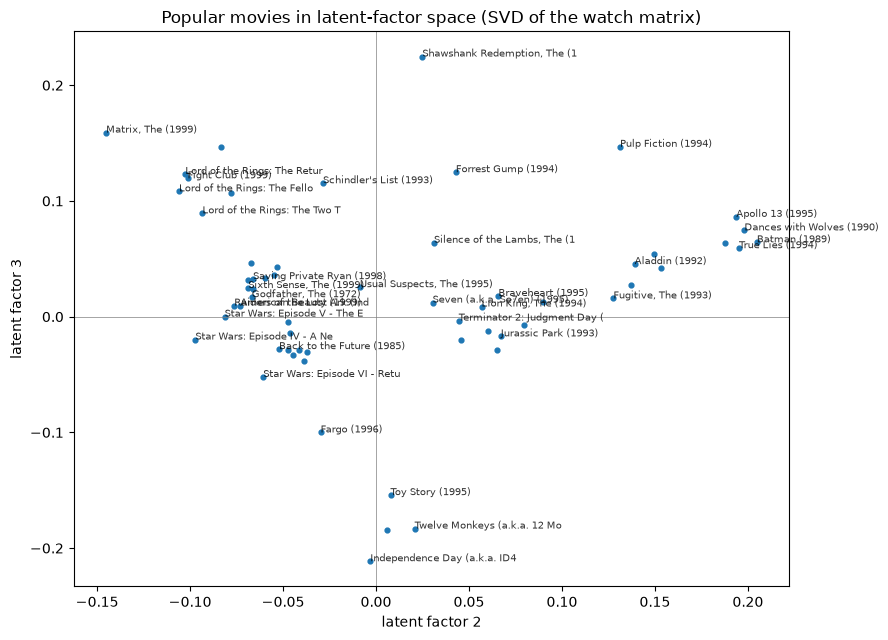

correlation of factor 1 with popularity: 0.96


In [22]:
svd2 = TruncatedSVD(n_components=3, random_state=SEED).fit(normalize(R_train.astype(np.float64)))
factors = svd2.components_[1:3].T                                                  # skip component 0 (≈ popularity)
famous = np.argsort(-pop_train)[:60]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(factors[famous, 0], factors[famous, 1], s=12, color="#1f77b4")
for idx in famous[:35]:
    ax.annotate(titles[idx][:28], (factors[idx, 0], factors[idx, 1]), fontsize=7, alpha=0.8)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set(xlabel="latent factor 2", ylabel="latent factor 3", title="Popular movies in latent-factor space (SVD of the watch matrix)")
plt.tight_layout()
plt.show()
print(f"correlation of factor 1 with popularity: {np.corrcoef(svd2.components_[0], pop_train)[0, 1]:.2f}")

### ✍️ Your Turn

With $\mu = 3.5$, $b_u = 0.2$, $b_i = -0.3$, $p_u = [1.0, 0.5]$ and $q_i = [0.4, -0.2]$, what rating does the biased MF model predict? Store it in `mf_prediction`.

In [23]:
mf_prediction = None  # TODO: your code here
check("mf_prediction", mf_prediction, 3.7, hint="μ + b_u + b_i + p_u · q_i = 3.5 + 0.2 − 0.3 + (0.4 − 0.1)")

⏳ mf_prediction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mf_prediction = 3.5 + 0.2 + (-0.3) + np.dot([1.0, 0.5], [0.4, -0.2])
check("mf_prediction", mf_prediction, 3.7)
```
</details>

> 💡 **Interview angle:** "Explain matrix factorization for recommendations." — represent users and items as $f$-dimensional vectors so a preference is their dot product plus user/item biases; learn them by minimizing squared error on *observed* entries with L2 regularization, via SGD ($O(\text{nnz}\cdot f)$ per epoch) or ALS (alternating closed-form ridge solves, embarrassingly parallel). Plain SVD needs a full matrix, so imputing missing entries biases it. The learned vectors double as embeddings for retrieval.

## 9. Implicit Feedback: Weighted ALS and BPR 🔴

With implicit data we don't have ratings to fit — only "interacted" or "not". **Hu, Koren & Volinsky (2008)** turn it into a weighted matrix factorization over **all** user–item cells:

$$\min_{X, Y}\sum_{u,i} c_{ui}\,\big(p_{ui} - x_u^\top y_i\big)^2 + \lambda\Big(\sum_u\lVert x_u\rVert^2 + \sum_i\lVert y_i\rVert^2\Big)$$

- **preference** $p_{ui} = 1$ if the user interacted, else $0$;
- **confidence** $c_{ui}$ is high for observed interactions (paper: $1 + \alpha r_{ui}$) and $1$ for unobserved — "didn't watch" is a *weak* negative.

All $U \times I$ cells are in the loss, so SGD would be hopeless; **ALS** makes it tractable. Fixing $Y$, each user's vector has the closed form

$$x_u = \big(Y^\top Y + Y^\top (C^u - I)\, Y + \lambda I\big)^{-1}\, Y^\top C^u p(u)$$

where $Y^\top Y$ is computed **once** for everyone and $Y^\top(C^u - I)Y$ only involves the user's $n_u$ observed items: $O(n_u f^2 + f^3)$ per user, and users are independent (parallel). Then fix $X$ and solve for items the same way.

**`implicit` 0.7 API (verified):** `fit(user_items)` takes a **users × items** CSR matrix; `alpha` multiplies the matrix values, and its solver uses confidence $c_{ui} = \alpha \cdot \text{value}$ for stored entries (the paper's $1 + \alpha r$ differs by the constant 1, which matters little once $\alpha r \gg 1$); `recommend(user_ids, user_items[user_ids], N)` filters already-seen items. The Build section reproduces its user update exactly.

In [24]:
def fit_implicit(model, R):
    with threadpoolctl.threadpool_limits(1, "blas"):                    # avoid BLAS threads fighting implicit's own threads
        start = time.perf_counter()
        model.fit(R, show_progress=False)
        return time.perf_counter() - start


def implicit_recs(model, R, k=K):
    ids, _ = model.recommend(np.arange(n_u), R, N=k, filter_already_liked_items=True)
    return ids


als_rows = []
for factors_ in [32, 128]:
    for alpha_ in [1.0, 10.0, 40.0]:
        for reg_ in [0.05, 1.0]:
            als_try = AlternatingLeastSquares(factors=factors_, regularization=reg_, alpha=alpha_, iterations=15, random_state=SEED, num_threads=N_THREADS)
            seconds = fit_implicit(als_try, R_train)
            als_rows.append({"factors": factors_, "alpha": alpha_, "regularization": reg_, "fit s": seconds} | eval_valid(implicit_recs(als_try, R_train)))
als_grid = pd.DataFrame(als_rows).round(4)
print(als_grid[["factors", "alpha", "regularization", "NDCG@k", "recall@k", "coverage", "fit s"]].to_string(index=False))
best_als = als_grid.loc[als_grid["NDCG@k"].idxmax()]
ALS_PARAMS = dict(factors=int(best_als["factors"]), alpha=float(best_als["alpha"]), regularization=float(best_als["regularization"]), iterations=15)
print(f"\nbest ALS on validation: {ALS_PARAMS} → NDCG@10 {best_als['NDCG@k']:.4f} (most popular: {baselines.loc['most popular', 'NDCG@k']:.4f})")

 factors  alpha  regularization  NDCG@k  recall@k  coverage  fit s
      32    1.0            0.05  0.0675    0.0833    0.0714 0.1376
      32    1.0            1.00  0.0679    0.0839    0.0690 0.1281
      32   10.0            0.05  0.0678    0.0875    0.1038 0.1542
      32   10.0            1.00  0.0683    0.0879    0.1015 0.1540
      32   40.0            0.05  0.0511    0.0646    0.1227 0.1533
      32   40.0            1.00  0.0497    0.0643    0.1241 0.1525
     128    1.0            0.05  0.0755    0.0944    0.0984 1.0160
     128    1.0            1.00  0.0762    0.0938    0.0933 1.0193
     128   10.0            0.05  0.0749    0.0908    0.1014 1.1738
     128   10.0            1.00  0.0770    0.0951    0.1028 1.1734
     128   40.0            0.05  0.0740    0.0872    0.0963 1.1707
     128   40.0            1.00  0.0764    0.0931    0.0963 1.1658

best ALS on validation: {'factors': 128, 'alpha': 10.0, 'regularization': 1.0, 'iterations': 15} → NDCG@10 0.0770 (most popular:

**BPR (Bayesian Personalized Ranking, Rendle et al. 2009)** skips confidence weights and optimizes the *ranking* directly: for sampled triples (user, watched item $i$, unwatched item $j$), maximize $\ln\sigma(\hat x_{ui} - \hat x_{uj})$ with SGD — i.e. push watched items above unwatched ones, a smooth version of per-user AUC.

In [25]:
bpr_rows = []
for lr_ in [0.01, 0.05]:
    bpr_try = BayesianPersonalizedRanking(factors=64, learning_rate=lr_, regularization=0.01, iterations=100, random_state=SEED, num_threads=N_THREADS)
    seconds = fit_implicit(bpr_try, R_train)
    bpr_rows.append({"learning_rate": lr_, "fit s": seconds} | eval_valid(implicit_recs(bpr_try, R_train)))
bpr_grid = pd.DataFrame(bpr_rows).round(4)
print(bpr_grid[["learning_rate", "NDCG@k", "recall@k", "coverage", "fit s"]].to_string(index=False))
BPR_LR = float(bpr_grid.loc[bpr_grid["NDCG@k"].idxmax(), "learning_rate"])

als_model = AlternatingLeastSquares(**ALS_PARAMS, random_state=SEED, num_threads=N_THREADS)
fit_implicit(als_model, R_train)
recs_als = implicit_recs(als_model, R_train)
similar_ids, similar_scores = als_model.similar_items(i_index[2571], N=6)
print("\nALS item embeddings — nearest to The Matrix:", "; ".join(titles[similar_ids[1:]]))

 learning_rate  NDCG@k  recall@k  coverage  fit s
          0.01  0.0538    0.0656    0.1253 0.7186
          0.05  0.0622    0.0744    0.2017 0.7177



ALS item embeddings — nearest to The Matrix: Fight Club (1999); Star Wars: Episode V - The Empire Strikes Back (1980); Saving Private Ryan (1998); Dark Knight, The (2008); Lord of the Rings: The Fellowship of the Ring, The (2001)


### ✍️ Your Turn

How many **distinct movies** appear across all users' ALS top-10 lists (`recs_als`)? Store the integer in `als_distinct_items`.

In [26]:
als_distinct_items = None  # TODO: your code here
check("als_distinct_items", als_distinct_items, len(np.unique(recs_als)), hint="np.unique over the whole recs_als array, then len().")

⏳ als_distinct_items: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
als_distinct_items = len(np.unique(recs_als))
print(f"{als_distinct_items} of {n_i:,} movies → catalog coverage {als_distinct_items / n_i:.1%}")
check("als_distinct_items", als_distinct_items, len(np.unique(recs_als)))
```
</details>

> 💡 **Interview angle:** "How does ALS for implicit feedback work, and why ALS instead of SGD?" — weighted MF over all cells with preference $p_{ui}\in\{0,1\}$ and confidence $c_{ui} = 1+\alpha r_{ui}$; with one side fixed, each user (or item) vector is a ridge-regression closed form whose expensive part $Y^\top Y$ is shared, so the cost is linear in the number of *observed* interactions and every user can be solved in parallel. SGD would have to sample the billions of zero cells. BPR is the pairwise-ranking alternative.

## 10. Two-Stage Systems: Candidates, Then Learning-to-Rank 🔴

Production recommenders rarely score every item with one model. They run a **funnel** ([ML System Design §8](../15_Interview_Prep/03_ML_System_Design.ipynb) covers the serving side):

```
 millions of items ──► candidate generation (cheap, high recall) ──► ~100s ──► ranking (rich features, precise) ──► top-10 ──► re-ranking (diversity, rules)
                       ALS / item-kNN / popularity / two-tower + ANN        GBM or neural ranker (LambdaRank)          MMR, freshness, business rules
```

- **Candidate generation** needs *recall@hundreds* and must be fast: matrix-factorization or **two-tower** embeddings (a user tower and an item tower trained so their dot product predicts engagement) retrieved with **approximate nearest-neighbour** search (FAISS, ScaNN, HNSW — see [Embeddings and Semantic Search §11](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb)).
- **Ranking** can afford expensive features for a few hundred candidates: the candidate scores themselves, item popularity and age, content match, user activity, context (time, device).

**A mini version.** Candidates = union of ALS top-50 and most-popular top-50 per user. Features per (user, candidate): ALS score, item-kNN score, content score, log popularity, item mean rating, user's number of interactions, genre overlap. **Labels** must come from a later time than the candidate models' training data: we fit the candidate generators on `train_df` and label candidates with the **validation** interactions, train a LightGBM `LGBMRanker` (LambdaRank, optimizing NDCG) on half of the users, and measure NDCG on the other half.

In [27]:
def candidate_features(R_hist, R_hist_ratings, als, S_item, pop, users, n_cand=50, knn_catalog=knn_items):
    """Candidates and features per user from models fitted on R_hist (never on the period being predicted)."""
    als_scores_all = als.user_factors[users] @ als.item_factors.T
    knn_all = item_knn_scores(R_hist[users], S_item, items=knn_catalog)
    knn_all = np.where(knn_all < -1e8, np.nan, knn_all)                        # outside the kNN catalog → missing feature
    content_all = content_scores(R_hist_ratings[users], item_tfidf)
    cand_als = top_k_unseen(als_scores_all, R_hist[users], n_cand)
    cand_pop = top_k_unseen(np.tile(pop, (len(users), 1)), R_hist[users], n_cand)
    item_sum = np.asarray(R_hist_ratings.sum(axis=0)).ravel()
    item_cnt = np.maximum(np.asarray(R_hist.sum(axis=0)).ravel(), 1)
    user_genres = normalize(R_hist[users] @ item_genres)
    rows = []
    for k_, u in enumerate(users):
        cands = np.union1d(cand_als[k_], cand_pop[k_])
        rows.append(pd.DataFrame({"user": u, "item": cands, "als": als_scores_all[k_, cands], "knn": knn_all[k_, cands],
                                  "content": content_all[k_, cands], "log_pop": np.log1p(pop[cands]),
                                  "item_mean": item_sum[cands] / item_cnt[cands], "user_activity": R_hist[u].nnz,
                                  "genre_match": normalize(item_genres[cands]) @ user_genres[k_]}))
    return pd.concat(rows, ignore_index=True)


FEATURE_COLS = ["als", "knn", "content", "log_pop", "item_mean", "user_activity", "genre_match"]
all_users = np.arange(n_u)
feats = candidate_features(R_train, R_train_ratings, als_model, S_items, pop_train, all_users)
feats["label"] = [int(item in valid_truth[u]) for u, item in zip(feats["user"], feats["item"])]
print(f"{len(feats):,} (user, candidate) rows, {feats.groupby('user').size().mean():.0f} candidates per user | "
      f"candidate recall: {feats.groupby('user')['label'].sum().sum() / sum(len(t) for t in valid_truth):.1%} of validation interactions are among the candidates")

split_gen = np.random.default_rng(SEED)
rank_train_users = np.sort(split_gen.choice(all_users, n_u // 2, replace=False))
rank_eval_users = np.setdiff1d(all_users, rank_train_users)
tr_rows = feats[feats["user"].isin(rank_train_users)].sort_values(["user", "item"])
ranker = lgb.LGBMRanker(objective="lambdarank", n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=20,
                        random_state=SEED, n_jobs=N_THREADS, verbose=-1)
ranker.fit(tr_rows[FEATURE_COLS], tr_rows["label"], group=tr_rows.groupby("user").size().to_numpy())


def ranked_lists(frame, score_col, users, k=K):
    out = np.zeros((n_u, k), dtype=int)
    for u, grp in frame[frame["user"].isin(users)].groupby("user"):
        out[u] = grp.nlargest(k, score_col)["item"].to_numpy()
    return out


ev_rows = feats[feats["user"].isin(rank_eval_users)].copy()
ev_rows["ltr"] = ranker.predict(ev_rows[FEATURE_COLS])
eval_user_set = set(rank_eval_users.tolist())
eval_truth_half = [valid_truth[u] if u in eval_user_set else set() for u in range(n_u)]
ltr_compare = pd.DataFrame([
    {"ranking of the same candidates": "ALS score only"} | evaluate(ranked_lists(ev_rows, "als", rank_eval_users), eval_truth_half, n_catalog=n_i),
    {"ranking of the same candidates": "popularity only"} | evaluate(ranked_lists(ev_rows, "log_pop", rank_eval_users), eval_truth_half, n_catalog=n_i),
    {"ranking of the same candidates": "LightGBM LambdaRank on 7 features"} | evaluate(ranked_lists(ev_rows, "ltr", rank_eval_users), eval_truth_half, n_catalog=n_i),
]).set_index("ranking of the same candidates")
print(ltr_compare[["NDCG@k", "recall@k", "MAP@k", "coverage"]].round(4).to_string())
gain = pd.Series(ranker.booster_.feature_importance("gain"), index=FEATURE_COLS).sort_values(ascending=False)
print(f"\nranker's top features by gain: {', '.join(gain.index[:3])} | LTR vs ALS-only NDCG change: "
      f"{ltr_compare.iloc[2]['NDCG@k'] - ltr_compare.iloc[0]['NDCG@k']:+.4f} (on {len(rank_eval_users)} held-out users)")

55,375 (user, candidate) rows, 91 candidates per user | candidate recall: 32.2% of validation interactions are among the candidates


                                   NDCG@k  recall@k   MAP@k  coverage
ranking of the same candidates                                       
ALS score only                     0.0855    0.1069  0.0464    0.0832
popularity only                    0.0414    0.0472  0.0201    0.0093
LightGBM LambdaRank on 7 features  0.0724    0.0938  0.0342    0.0678

ranker's top features by gain: als, genre_match, content | LTR vs ALS-only NDCG change: -0.0131 (on 305 held-out users)


**Reading the result:** a ranker only helps when its features add information the best candidate score lacks. Here it has 7 simple features and about 300 training users, so read the printed NDCG change honestly — if it doesn't beat the ALS score alone, that is a real finding, not a bug. Production rankers win with far richer signals (recency, context, impressions, dwell time) and millions of labelled impressions.

**Leakage traps in LTR:** features must be computed only from data before the label period (we fit ALS, kNN, content, and popularity on `train_df` and labelled with the later validation interactions); rankers are grouped **per user** (`group=`), and train/eval users are disjoint. For the mini project, the same recipe shifts forward one period: candidate models on `train_full`, labels from test — which is why we can't train a ranker on test labels, and instead reuse the ranker trained on validation labels.

> 💡 **Interview angle:** "Why do recommenders use two stages?" — scoring millions of items with a feature-rich model per request is too slow, so a cheap high-recall stage (MF/two-tower embeddings + ANN, co-visitation, popularity) picks hundreds of candidates and a precise ranker (GBM or neural, trained with a ranking loss like LambdaRank on logged impressions) orders them; a re-ranker applies diversity and business rules. Each stage has its own metric: recall@N for retrieval, NDCG/AUC for ranking.

## 11. Beyond Accuracy: Popularity Bias, Diversity, and Feedback Loops 🟡

A list of ten near-identical blockbusters can score well offline and still be a bad product. Three levers:

1. **Popularity-bias correction:** divide scores by $\text{popularity}^\beta$ to give the tail a chance.
2. **Diversity re-ranking with MMR (Maximal Marginal Relevance, Carbonell & Goldstein 1998):** build the list greedily; at each step pick the candidate maximizing $\lambda\cdot\text{relevance} - (1-\lambda)\cdot\max_{j\in\text{list}}\text{sim}(i, j)$.
3. **Watching for feedback loops:** a recommender trained on clicks it caused learns its own biases; exposure concentrates on what was already shown.

In [28]:
def mmr_rerank(candidates, relevance, similarity, k=K, lam=0.7):
    """Greedy MMR. candidates: item ids; relevance: scores (same order); similarity: (len, len) matrix over candidates."""
    rel = (relevance - relevance.min()) / (np.ptp(relevance) + 1e-12)          # put relevance on [0, 1] like similarity
    chosen = [int(np.argmax(rel))]
    while len(chosen) < k:
        redundancy = similarity[:, chosen].max(axis=1)
        mmr = lam * rel - (1 - lam) * redundancy
        mmr[chosen] = -np.inf
        chosen.append(int(np.argmax(mmr)))
    return np.asarray(candidates)[chosen]


als_scores = als_model.user_factors @ als_model.item_factors.T
cand50 = top_k_unseen(als_scores, R_train, 50)
genre_norm = normalize(item_genres)
beyond_rows = []
for lam in [1.0, 0.7, 0.4]:
    recs_mmr = np.array([mmr_rerank(cand50[u], als_scores[u, cand50[u]], genre_norm[cand50[u]] @ genre_norm[cand50[u]].T, lam=lam) for u in range(n_u)])
    beyond_rows.append({"re-ranking": f"MMR λ={lam}" + (" (= plain ALS)" if lam == 1.0 else "")} | eval_valid(recs_mmr))
for beta in [0.3, 0.6]:
    recs_debias = top_k_unseen(np.where(als_scores > 0, als_scores, 0) / np.maximum(pop_train, 1) ** beta, R_train)
    beyond_rows.append({"re-ranking": f"ALS score / popularity^{beta}"} | eval_valid(recs_debias))
beyond = pd.DataFrame(beyond_rows).set_index("re-ranking")
print(beyond[["NDCG@k", "recall@k", "diversity", "novelty", "coverage"]].round(4).to_string())
plain = beyond.iloc[0]
most_diverse = beyond["diversity"].idxmax()
print(f"\n{most_diverse}: diversity {plain['diversity']:.3f} → {beyond.loc[most_diverse, 'diversity']:.3f}, "
      f"NDCG@10 {plain['NDCG@k']:.4f} → {beyond.loc[most_diverse, 'NDCG@k']:.4f} — the accuracy/diversity trade-off, measured")

                            NDCG@k  recall@k  diversity  novelty  coverage
re-ranking                                                                
MMR λ=1.0 (= plain ALS)     0.0770    0.0951     0.7102   2.9251    0.1028
MMR λ=0.7                   0.0738    0.0892     0.7569   2.9366    0.1045
MMR λ=0.4                   0.0659    0.0793     0.8133   3.0088    0.1061
ALS score / popularity^0.3  0.0509    0.0652     0.6934   4.8936    0.2200
ALS score / popularity^0.6  0.0086    0.0125     0.7084   8.5021    0.1186

MMR λ=0.4: diversity 0.710 → 0.813, NDCG@10 0.0770 → 0.0659 — the accuracy/diversity trade-off, measured


**A feedback loop in miniature.** Start from the real training popularity. Each round, every user is shown the most-popular top-10 they haven't seen and "watches" each shown item with probability 5%; those watches are added to the counts the next round's popularity is computed from. We track the **Gini coefficient** of item exposure (0 = equal, 1 = one item gets everything) — a simulation, clearly labelled, on real starting data.

Gini of item interaction counts: start 0.7153 → after 10 rounds 0.7245 (more concentrated)


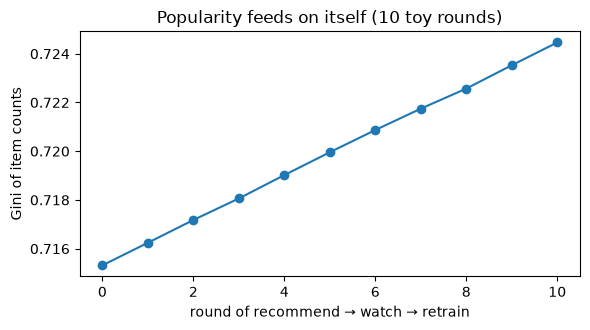

In [29]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))


loop_gen = np.random.default_rng(SEED)
counts_loop = pop_train.astype(float).copy()
seen_loop = R_train.tolil(copy=True)
gini_track = [gini(counts_loop)]
for round_ in range(10):
    shown = top_k_unseen(np.tile(counts_loop, (n_u, 1)), seen_loop.tocsr())
    accepted = loop_gen.random(shown.shape) < 0.05
    for u, items in zip(*np.nonzero(accepted)):
        seen_loop[u, shown[u, items]] = 1
        counts_loop[shown[u, items]] += 1
    gini_track.append(gini(counts_loop))
print(f"Gini of item interaction counts: start {gini_track[0]:.4f} → after 10 rounds {gini_track[-1]:.4f} "
      f"({'more' if gini_track[-1] > gini_track[0] else 'less'} concentrated)")
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(gini_track, "o-")
ax.set(xlabel="round of recommend → watch → retrain", ylabel="Gini of item counts", title="Popularity feeds on itself (10 toy rounds)")
plt.tight_layout()
plt.show()

**Mitigations:** reserve exploration traffic (ε-greedy or contextual bandits), log *impressions* and propensities so you can debias training (inverse propensity weighting), add diversity and freshness constraints, and monitor catalog coverage and creator/item exposure over time — see [ML System Design §13 on feedback loops and position bias](../15_Interview_Prep/03_ML_System_Design.ipynb).

### ✍️ Your Turn

Compute the Gini coefficient of the exposure counts `[1, 1, 1, 1]` and of `[0, 0, 0, 10]` with the `gini` helper, and store them as a list `[gini_equal, gini_concentrated]` in `gini_pair`.

In [30]:
gini_pair = None  # TODO: your code here
check("gini_pair", gini_pair, [0.0, 0.75], hint="gini([1, 1, 1, 1]) and gini([0, 0, 0, 10]); with n items the maximum Gini is (n − 1)/n.")

⏳ gini_pair: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gini_pair = [gini([1, 1, 1, 1]), gini([0, 0, 0, 10])]
check("gini_pair", gini_pair, [0.0, 0.75])
```
With 4 items the most concentrated possible distribution has Gini (4 − 1)/4 = 0.75.
</details>

> 💡 **Interview angle:** "Your recommender keeps showing the same popular items. What do you do?" — measure it (coverage, Gini of exposure, novelty), then re-rank for diversity (MMR, calibration to the user's genre mix), penalize popularity in scoring, add exploration, and debias training with logged propensities; evaluate the trade-off online, because NDCG on logged data rewards popularity by construction.

## 🔧 Build It From Scratch

Three core pieces, rebuilt and checked:

**(a) Ranking metrics.** The loop functions from section 3 against hand-computed values and against `sklearn.metrics.ndcg_score` on hundreds of random lists; then the vectorized `evaluate` against the loops and against `ndcg_score` on the real ALS validation lists.

**(b) Matrix factorization with biases, trained by mini-batch SGD in NumPy.** Each batch computes errors $e = r - (\mu + b_u + b_i + p_u^\top q_i)$ and applies the SGD updates with `np.add.at` (so a user appearing twice in a batch gets both updates). Validation RMSE picks the best epoch (early stopping) — and it must **beat the bias baseline**.

**(c) The implicit-ALS user update.** With item factors $Y$ fixed, $x_u = (Y^\top Y + Y^\top(C^u - I)Y + \lambda I)^{-1} Y^\top C^u p(u)$ with $c_{ui} = \alpha\cdot\text{value}$ for the user's observed items — solved with `np.linalg.solve` and compared with `implicit`'s own `recalculate_user`.

In [31]:
hand_cases = [
    (["A", "B", "C", "D", "E"], {"B", "E", "F"}, 5, {"precision": 2 / 5, "recall": 2 / 3, "ap": (1 / 2 + 2 / 5) / 3,
                                                   "ndcg": (1 / np.log2(3) + 1 / np.log2(6)) / (1 + 1 / np.log2(3) + 1 / np.log2(4)), "rr": 1 / 2}),
    (["X", "Y", "Z"], {"Z"}, 3, {"precision": 1 / 3, "recall": 1.0, "ap": 1 / 3, "ndcg": 0.5, "rr": 1 / 3}),
    (["P", "Q"], {"R"}, 2, {"precision": 0.0, "recall": 0.0, "ap": 0.0, "ndcg": 0.0, "rr": 0.0}),
    (["A", "B", "C", "D"], {"A", "B", "C", "D", "E", "F"}, 4, {"precision": 1.0, "recall": 4 / 6, "ap": 1.0, "ndcg": 1.0, "rr": 1.0}),
]
for recs_h, rel_h, k_h, expected in hand_cases:
    got = {"precision": precision_at_k(recs_h, rel_h, k_h), "recall": recall_at_k(recs_h, rel_h, k_h), "ap": average_precision_at_k(recs_h, rel_h, k_h),
           "ndcg": ndcg_at_k(recs_h, rel_h, k_h), "rr": reciprocal_rank_at_k(recs_h, rel_h, k_h)}
    assert all(np.isclose(got[m], expected[m]) for m in expected), (recs_h, got, expected)
print(f"✅ {len(hand_cases)} hand-computed cases match (including a user with no hits and a user with more relevant items than k)")

gen_metrics = np.random.default_rng(0)
for trial in range(300):
    n_items_t, k_t = 40, int(gen_metrics.integers(1, 15))
    relevant_t = set(gen_metrics.choice(n_items_t, int(gen_metrics.integers(1, 10)), replace=False).tolist())
    recs_t = gen_metrics.permutation(n_items_t)[:k_t]
    y_true_t = np.zeros(n_items_t)
    y_true_t[list(relevant_t)] = 1
    y_score_t = np.zeros(n_items_t)
    y_score_t[recs_t] = np.arange(k_t, 0, -1)                       # the recommended order, best first; everything else ties at 0
    assert np.isclose(ndcg_at_k(list(recs_t), relevant_t, k_t), ndcg_score([y_true_t], [y_score_t], k=k_t))
print("✅ ndcg_at_k equals sklearn.metrics.ndcg_score on 300 random lists")

scores_als_valid = als_model.user_factors @ als_model.item_factors.T
recs_check = top_k_unseen(scores_als_valid, R_train)
users_with_truth = [u for u in range(n_u) if valid_truth[u]]
vectorized = evaluate(recs_check, valid_truth)
loops = {"precision@k": np.mean([precision_at_k(list(recs_check[u]), valid_truth[u], K) for u in users_with_truth]),
         "recall@k": np.mean([recall_at_k(list(recs_check[u]), valid_truth[u], K) for u in users_with_truth]),
         "MAP@k": np.mean([average_precision_at_k(list(recs_check[u]), valid_truth[u], K) for u in users_with_truth]),
         "NDCG@k": np.mean([ndcg_at_k(list(recs_check[u]), valid_truth[u], K) for u in users_with_truth]),
         "MRR@k": np.mean([reciprocal_rank_at_k(list(recs_check[u]), valid_truth[u], K) for u in users_with_truth])}
assert all(np.isclose(vectorized[m], loops[m], atol=1e-12) for m in loops)
seen_dense = R_train.toarray() > 0
masked_scores = np.where(seen_dense, scores_als_valid.min() - 1.0, scores_als_valid)[users_with_truth]
y_true_real = np.zeros((len(users_with_truth), n_i))
for row_, u in enumerate(users_with_truth):
    y_true_real[row_, list(valid_truth[u])] = 1
sk_real = ndcg_score(y_true_real, masked_scores, k=K)
assert np.isclose(vectorized["NDCG@k"], sk_real, atol=1e-6)
print(f"✅ vectorized evaluate == loop metrics on {len(users_with_truth)} real users; NDCG@10 {vectorized['NDCG@k']:.6f} == sklearn {sk_real:.6f}")
del seen_dense, masked_scores, y_true_real

✅ 4 hand-computed cases match (including a user with no hits and a user with more relevant items than k)
✅ ndcg_at_k equals sklearn.metrics.ndcg_score on 300 random lists


✅ vectorized evaluate == loop metrics on 610 real users; NDCG@10 0.077025 == sklearn 0.077025


✅ SGD matrix factorization: validation RMSE 0.9008 < bias baseline 0.9071 (−0.0064) | best epoch 50 | 2.5s for 60 epochs
   with weak regularization (λ=0.01): best validation RMSE 0.9082 at epoch 11 — it overfits sooner


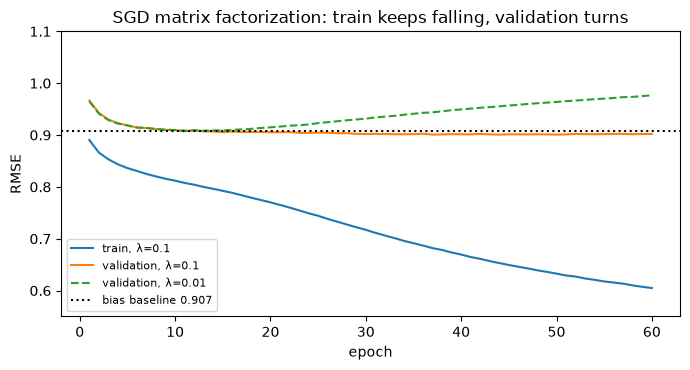

In [32]:
class BiasedMF:
    """r̂ = μ + b_u + b_i + p_u·q_i, trained by mini-batch SGD with L2 regularization; early stopping on validation RMSE."""

    def __init__(self, n_factors=32, lr=0.01, reg=0.1, n_epochs=60, batch_size=512, seed=SEED):
        self.n_factors, self.lr, self.reg, self.n_epochs, self.batch_size, self.seed = n_factors, lr, reg, n_epochs, batch_size, seed

    @staticmethod
    def _arrays(df):
        return u_index[df["userId"]].to_numpy(), i_index[df["movieId"]].to_numpy(), df["rating"].to_numpy(float)

    def predict_pairs(self, u, i):
        return np.clip(self.mu + self.b_u[u] + self.b_i[i] + np.sum(self.P[u] * self.Q[i], axis=1), 0.5, 5.0)

    def rmse(self, df):
        u, i, r = self._arrays(df)
        return float(np.sqrt(np.mean((r - self.predict_pairs(u, i)) ** 2)))

    def fit(self, df, valid=None, n_epochs=None):
        u, i, r = self._arrays(df)
        gen = np.random.default_rng(self.seed)
        self.mu = r.mean()
        self.b_u, self.b_i = np.zeros(n_u), np.zeros(n_i)
        self.P = gen.normal(0, 0.1, (n_u, self.n_factors))
        self.Q = gen.normal(0, 0.1, (n_i, self.n_factors))
        self.history, best = [], (np.inf, 0, None)
        for epoch in range(1, (n_epochs or self.n_epochs) + 1):
            order = gen.permutation(len(r))
            for start in range(0, len(r), self.batch_size):
                b = order[start:start + self.batch_size]
                ub, ib = u[b], i[b]
                pu, qi = self.P[ub], self.Q[ib]
                err = r[b] - (self.mu + self.b_u[ub] + self.b_i[ib] + np.sum(pu * qi, axis=1))
                np.add.at(self.b_u, ub, self.lr * (err - self.reg * self.b_u[ub]))
                np.add.at(self.b_i, ib, self.lr * (err - self.reg * self.b_i[ib]))
                np.add.at(self.P, ub, self.lr * (err[:, None] * qi - self.reg * pu))
                np.add.at(self.Q, ib, self.lr * (err[:, None] * pu - self.reg * qi))
            entry = {"epoch": epoch, "train RMSE": self.rmse(df)}
            if valid is not None:
                entry["validation RMSE"] = self.rmse(valid)
                if entry["validation RMSE"] < best[0]:
                    best = (entry["validation RMSE"], epoch, (self.b_u.copy(), self.b_i.copy(), self.P.copy(), self.Q.copy()))
            self.history.append(entry)
        if valid is not None:                                                   # restore the best epoch
            self.b_u, self.b_i, self.P, self.Q = best[2]
            self.best_epoch_ = best[1]
        return self

    def score_all(self):
        return self.mu + self.b_u[:, None] + self.b_i[None, :] + self.P @ self.Q.T


start = time.perf_counter()
mf = BiasedMF(n_factors=32, lr=0.01, reg=0.1, n_epochs=60).fit(train_df, valid=valid_df)
t_mf = time.perf_counter() - start
mf_low_reg = BiasedMF(n_factors=32, lr=0.01, reg=0.01, n_epochs=60).fit(train_df, valid=valid_df)
rmse_bias_valid = rmse_bias(bias_model, valid_df)
rmse_mf_valid = mf.rmse(valid_df)
assert rmse_mf_valid < rmse_bias_valid, (rmse_mf_valid, rmse_bias_valid)
print(f"✅ SGD matrix factorization: validation RMSE {rmse_mf_valid:.4f} < bias baseline {rmse_bias_valid:.4f} "
      f"(−{rmse_bias_valid - rmse_mf_valid:.4f}) | best epoch {mf.best_epoch_} | {t_mf:.1f}s for 60 epochs")
print(f"   with weak regularization (λ=0.01): best validation RMSE {mf_low_reg.rmse(valid_df):.4f} at epoch {mf_low_reg.best_epoch_} — it overfits sooner")

hist, hist_low = pd.DataFrame(mf.history), pd.DataFrame(mf_low_reg.history)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(hist["epoch"], hist["train RMSE"], label="train, λ=0.1")
ax.plot(hist["epoch"], hist["validation RMSE"], label="validation, λ=0.1")
ax.plot(hist_low["epoch"], hist_low["validation RMSE"], "--", label="validation, λ=0.01")
ax.axhline(rmse_bias_valid, color="k", ls=":", label=f"bias baseline {rmse_bias_valid:.3f}")
ax.set(xlabel="epoch", ylabel="RMSE", ylim=(0.55, 1.1), title="SGD matrix factorization: train keeps falling, validation turns")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [33]:
def als_user_factor(Y, user_row, alpha, reg):
    """Closed-form implicit-ALS update for one user: solve (YᵀY + Yᵀ(Cᵘ−I)Y + λI) x = YᵀCᵘp with c = α·value on observed items."""
    Y = Y.astype(np.float64)
    idx = user_row.indices
    conf = alpha * user_row.data.astype(np.float64)
    A = Y.T @ Y + (Y[idx].T * (conf - 1.0)) @ Y[idx] + reg * np.eye(Y.shape[1])
    b = Y[idx].T @ conf                                                         # preference p = 1 on observed items
    return np.linalg.solve(A, b)


check_users = [0, 1, 100, 300, n_u - 1]
max_diff = 0.0
for u in check_users:
    ours_u = als_user_factor(als_model.item_factors, R_train[u], ALS_PARAMS["alpha"], ALS_PARAMS["regularization"])
    theirs_u = als_model.recalculate_user(u, R_train[u])
    assert np.allclose(ours_u, theirs_u, rtol=1e-3, atol=1e-4), u
    max_diff = max(max_diff, float(np.abs(ours_u - theirs_u).max()))
stored_gap = float(np.abs(als_model.recalculate_user(check_users[1], R_train[check_users[1]]) - als_model.user_factors[check_users[1]]).max())
print(f"✅ closed-form user update == implicit.recalculate_user for users {check_users} (max |diff| {max_diff:.1e}, float32 vs float64)")
print(f"   the stored user_factors differ by up to {stored_gap:.3f}: in each ALS iteration users are solved *before* items are updated, "
      f"so they were computed against the previous item factors")
print(f"   cost per user: one {ALS_PARAMS['factors']}×{ALS_PARAMS['factors']} solve after an O(n_u·f²) sum over the user's own {R_train[check_users[1]].nnz} items — YᵀY is shared by all users")

✅ closed-form user update == implicit.recalculate_user for users [0, 1, 100, 300, 609] (max |diff| 2.4e-05, float32 vs float64)
   the stored user_factors differ by up to 0.006: in each ALS iteration users are solved *before* items are updated, so they were computed against the previous item factors
   cost per user: one 128×128 solve after an O(n_u·f²) sum over the user's own 14 items — YᵀY is shared by all users


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Recommending what the user already watched
Without filtering, the model's highest scores often go to items already in the user's history — slots wasted on things they won't click again (for re-watchable items like music this can be desired; measure it).

In [34]:
ids_nofilter, _ = als_model.recommend(np.arange(n_u), R_train, N=K, filter_already_liked_items=False)
wasted = np.mean([len(set(ids_nofilter[u]) & set(R_train[u].indices)) / K for u in range(n_u)])
print(f"❌ unfiltered ALS: {wasted:.0%} of the top-10 slots are already-watched movies | NDCG@10 {evaluate(ids_nofilter, valid_truth)['NDCG@k']:.4f}")
print(f"✅ filtered ALS:   0% wasted | NDCG@10 {evaluate(recs_als, valid_truth)['NDCG@k']:.4f}")

❌ unfiltered ALS: 94% of the top-10 slots are already-watched movies | NDCG@10 0.0055
✅ filtered ALS:   0% wasted | NDCG@10 0.0770


### ❌ Pitfall 2 — Picking the recommender with the best RMSE
RMSE rewards predicting stars well for *any* movie; the product needs the right movies at the top.

In [35]:
recs_mf_rating = top_k_unseen(mf.score_all(), R_train)
rmse_vs_rank = pd.DataFrame([
    {"model": "bias model (rank by b_i)", "validation RMSE": rmse_bias_valid, "NDCG@10": eval_valid(recs_bias)["NDCG@k"]},
    {"model": "SGD matrix factorization (rank by predicted rating)", "validation RMSE": rmse_mf_valid, "NDCG@10": eval_valid(recs_mf_rating)["NDCG@k"]},
    {"model": "implicit ALS (no rating prediction)", "validation RMSE": np.nan, "NDCG@10": eval_valid(recs_als)["NDCG@k"]},
    {"model": "most popular (no rating prediction)", "validation RMSE": np.nan, "NDCG@10": baselines.loc["most popular", "NDCG@k"]},
]).set_index("model").round(4)
print(rmse_vs_rank.to_string())
print(f"❌ the lowest-RMSE model ranks {int(rmse_vs_rank['NDCG@10'].rank(ascending=False).iloc[1])} of {len(rmse_vs_rank)} by NDCG | "
      f"✅ choose with the metric that matches the product: {rmse_vs_rank['NDCG@10'].idxmax()} wins NDCG@10")

                                                     validation RMSE  NDCG@10
model                                                                        
bias model (rank by b_i)                                      0.9071   0.0152
SGD matrix factorization (rank by predicted rating)           0.9008   0.0010
implicit ALS (no rating prediction)                              NaN   0.0770
most popular (no rating prediction)                              NaN   0.0447
❌ the lowest-RMSE model ranks 4 of 4 by NDCG | ✅ choose with the metric that matches the product: implicit ALS (no rating prediction) wins NDCG@10


### ❌ Pitfall 3 — Passing an items × users matrix to `implicit` ≥ 0.5
Older `implicit` versions took `item_users`; since 0.5 `fit` expects **users × items**. The swapped matrix fits without complaint — the "users" are now movies.

In [36]:
wrong_als = AlternatingLeastSquares(factors=32, iterations=5, random_state=SEED, num_threads=N_THREADS)
fit_implicit(wrong_als, R_train.T.tocsr())
print(f"❌ fitted on items×users: user_factors {wrong_als.user_factors.shape}, item_factors {wrong_als.item_factors.shape} — no warning")
try:
    wrong_recs = implicit_recs(wrong_als, R_train)
    print(f"   recommend() ran, but item ids only go up to {wrong_recs.max()} (the model thinks there are {wrong_als.item_factors.shape[0]} items) "
          f"→ NDCG@10 {evaluate(wrong_recs, valid_truth)['NDCG@k']:.4f}")
except Exception as err:                                                        # implicit validates shapes at recommend time
    print(f"   recommend() then fails: {type(err).__name__}: {str(err)[:100]}")
assert als_model.user_factors.shape[0] == n_u and als_model.item_factors.shape[0] == n_i
print(f"✅ users×items: user_factors {als_model.user_factors.shape}, item_factors {als_model.item_factors.shape} — assert the shapes after fitting")

❌ fitted on items×users: user_factors (9724, 32), item_factors (610, 32) — no warning
   recommend() then fails: IndexError: index 632 is out of bounds for axis 1 with size 610
✅ users×items: user_factors (610, 128), item_factors (9724, 128) — assert the shapes after fitting


### ❌ Pitfall 4 — Sampled metrics (rank the positive among 100 random negatives)
A popular shortcut scores each held-out item against only 100 random unseen items. It's fast, but it inflates every model and can **change which model wins** (Krichene & Rendle, 2020), because random negatives are mostly obscure movies any model beats.

In [37]:
def sampled_hit_rate(scores, R_seen, truth, n_neg=100, k=K, seed=SEED):
    gen = np.random.default_rng(seed)
    hits = []
    for u in range(n_u):
        if not truth[u]:
            continue
        positive = sorted(truth[u])[0]
        pool = np.setdiff1d(np.arange(n_i), np.r_[R_seen[u].indices, sorted(truth[u])])
        candidates = np.r_[positive, gen.choice(pool, n_neg, replace=False)]
        s = scores[u, candidates]
        rank = 1 + np.sum(s[1:] > s[0]) + 0.5 * np.sum(s[1:] == s[0])            # ties count half
        hits.append(rank <= k)
    return float(np.mean(hits))


model_scores = {"most popular": np.tile(pop_train.astype(float), (n_u, 1)), "content-based": content_scores(R_train_ratings, item_tfidf),
                "item-kNN": item_knn_scores(R_train, S_items), "implicit ALS": scores_als_valid}
full_hr = {"most popular": baselines.loc["most popular", "hit rate@k"], "content-based": content_row["hit rate@k"],
           "item-kNN": item_knn_row["hit rate@k"], "implicit ALS": eval_valid(recs_als)["hit rate@k"]}
sampled_df = pd.DataFrame({"sampled HR@10 (1 positive + 100 negatives)": {m: sampled_hit_rate(s_, R_train, valid_truth) for m, s_ in model_scores.items()},
                           "full-ranking HR@10": full_hr}).round(4)
print(sampled_df.to_string())
order_sampled = list(sampled_df.iloc[:, 0].sort_values(ascending=False).index)
order_full = list(sampled_df.iloc[:, 1].sort_values(ascending=False).index)
print(f"❌ sampled ranking of models: {order_sampled}")
print(f"✅ full ranking of models:    {order_full} → {'same order' if order_sampled == order_full else 'the order CHANGES'}; always rank against the whole catalog when you can")
del model_scores

               sampled HR@10 (1 positive + 100 negatives)  full-ranking HR@10
most popular                                       0.7311              0.1967
content-based                                      0.1934              0.0262
item-kNN                                           0.7525              0.2869
implicit ALS                                       0.6541              0.3000
❌ sampled ranking of models: ['item-kNN', 'most popular', 'implicit ALS', 'content-based']
✅ full ranking of models:    ['implicit ALS', 'item-kNN', 'most popular', 'content-based'] → the order CHANGES; always rank against the whole catalog when you can


### ❌ Pitfall 5 — Normalizing NDCG by an ideal list of length k instead of min(k, |relevant|)
Every validation user has 5 relevant movies. If IDCG assumes 10 relevant slots, even a perfect list can't reach 1.

In [38]:
disc = 1 / np.log2(np.arange(2, K + 2))
perfect_hits = np.r_[np.ones(5), np.zeros(K - 5)]
print(f"❌ a perfect list for a user with 5 relevant items, IDCG over k=10 slots: NDCG = {(perfect_hits @ disc) / disc.sum():.3f}")
print(f"✅ IDCG over min(k, |R|) = 5 slots: NDCG = {(perfect_hits @ disc) / disc[:5].sum():.3f}")
hits_als = np.array([[item in valid_truth[u] for item in recs_als[u]] for u in range(n_u)], dtype=float)
print(f"on real ALS lists: wrong normalizer {np.mean(hits_als @ disc / disc.sum()):.4f} vs correct {evaluate(recs_als, valid_truth)['NDCG@k']:.4f} — "
      "and the wrong one penalizes users with few relevant items, so segment comparisons get distorted")

❌ a perfect list for a user with 5 relevant items, IDCG over k=10 slots: NDCG = 0.649
✅ IDCG over min(k, |R|) = 5 slots: NDCG = 1.000
on real ALS lists: wrong normalizer 0.0500 vs correct 0.0770 — and the wrong one penalizes users with few relevant items, so segment comparisons get distorted


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Precision and recall at k
The top-5 list is `[3, 7, 1, 9, 4]` and the relevant items are `{1, 4, 8, 10}`. Store `[precision@5, recall@5]` in `pr_at_5`.

In [39]:
pr_at_5 = None  # TODO
check("pr_at_5", pr_at_5, [0.4, 0.5], hint="2 hits (1 and 4): precision = hits / 5, recall = hits / 4.")

⏳ pr_at_5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
recs_ex, rel_ex = [3, 7, 1, 9, 4], {1, 4, 8, 10}
hits_ex = len(set(recs_ex) & rel_ex)
pr_at_5 = [hits_ex / 5, hits_ex / len(rel_ex)]
check("pr_at_5", pr_at_5, [0.4, 0.5])
```
</details>

### 🟢 Exercise 2 — Mean reciprocal rank
Three users: user A's first relevant item is at rank 1, user B's at rank 3, user C has no relevant item in the top-10. Store the MRR in `mrr_three`.

In [40]:
mrr_three = None  # TODO
check("mrr_three", mrr_three, (1 + 1 / 3 + 0) / 3, hint="Average of 1/rank per user, with 0 for a user without any hit.")

⏳ mrr_three: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mrr_three = np.mean([1 / 1, 1 / 3, 0.0])         # ≈ 0.444
check("mrr_three", mrr_three, (1 + 1 / 3 + 0) / 3)
```
</details>

### 🟢 Exercise 3 — A regularized item bias
A movie has three ratings whose residuals after subtracting $\mu + b_u$ are `[1.0, 0.5, 1.5]`. With $\lambda = 3$, compute $b_i = \frac{\sum \text{residuals}}{\lambda + n}$ and store it in `shrunk_bias`.

In [41]:
shrunk_bias = None  # TODO
check("shrunk_bias", shrunk_bias, 0.5, hint="(1.0 + 0.5 + 1.5) / (3 + 3)")

⏳ shrunk_bias: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
residuals = np.array([1.0, 0.5, 1.5])
shrunk_bias = residuals.sum() / (3 + len(residuals))  # 0.5, half of the unregularized mean residual 1.0
check("shrunk_bias", shrunk_bias, 0.5)
```
With only three ratings the estimate is pulled halfway toward 0; with 300 ratings it would barely move.
</details>

### 🟡 Exercise 4 — Item–item cosine similarity
`M_small` is a users × items 0/1 matrix. Compute the 3 × 3 **item–item** cosine similarity matrix (NumPy only) and store it in `item_cos`.

In [42]:
from sklearn.metrics.pairwise import cosine_similarity

M_small = np.array([[1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=float)
item_cos = None  # TODO
check("item_cos", item_cos, cosine_similarity(M_small.T), hint="Columns are items: G = M.T @ M; divide by the outer product of column norms.")

⏳ item_cos: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from sklearn.metrics.pairwise import cosine_similarity

M_small = np.array([[1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 1, 1]], dtype=float)
gram = M_small.T @ M_small                       # co-occurrence counts between items
col_norms = np.sqrt(np.diag(gram))
item_cos = gram / np.outer(col_norms, col_norms)
check("item_cos", item_cos, cosine_similarity(M_small.T))
```
On 0/1 data the numerator counts users who interacted with both items, and the denominator corrects for each item's popularity.
</details>

### 🟡 Exercise 5 — NDCG with graded relevance
Six items have graded relevance `y_true = [3, 2, 0, 0, 1, 2]` and model scores `y_score = [0.9, 0.2, 0.8, 0.1, 0.5, 0.3]`. Compute **NDCG@4** with *linear* gains (DCG = Σ rel / log₂(rank + 1), the convention scikit-learn uses) and store it in `graded_ndcg`.

In [43]:
y_true_g = np.array([3, 2, 0, 0, 1, 2], dtype=float)
y_score_g = np.array([0.9, 0.2, 0.8, 0.1, 0.5, 0.3])
graded_ndcg = None  # TODO
check("graded_ndcg", graded_ndcg, ndcg_score([y_true_g], [y_score_g], k=4),
      hint="Order items by score, take the first 4 gains → DCG; sort y_true descending, take 4 → IDCG.")

⏳ graded_ndcg: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_true_g = np.array([3, 2, 0, 0, 1, 2], dtype=float)
y_score_g = np.array([0.9, 0.2, 0.8, 0.1, 0.5, 0.3])
discounts_g = 1 / np.log2(np.arange(2, 6))
dcg_g = y_true_g[np.argsort(-y_score_g)[:4]] @ discounts_g
idcg_g = np.sort(y_true_g)[::-1][:4] @ discounts_g
graded_ndcg = dcg_g / idcg_g
check("graded_ndcg", graded_ndcg, ndcg_score([y_true_g], [y_score_g], k=4))
```
Many papers use exponential gains $2^{rel} - 1$ instead, which reward highly relevant items much more — always say which convention you report.
</details>

### 🔴 Exercise 6 — The implicit-ALS item update (interview-style)
With the **user** factors of `als_model` fixed, derive and implement the closed-form update of one **item** vector for *The Matrix*: $y_i = (X^\top X + X^\top(C^i - I)X + \lambda I)^{-1} X^\top C^i p(i)$, where $C^i$ holds $c_{ui} = \alpha \cdot \text{value}$ for the users who watched the item. Use `item_col` (the item's row of the items × users matrix) and `ALS_PARAMS`. Store the vector in `item_vector`; the checker compares with `implicit`'s `recalculate_item`.

In [44]:
item_pos = i_index[2571]
item_col = R_train.T.tocsr()[item_pos]
item_vector = None  # TODO
check("item_vector", item_vector, als_model.recalculate_item(item_pos, item_col), atol=1e-3,
      hint="Swap roles: X = als_model.user_factors (float64); idx = item_col.indices; conf = alpha · item_col.data; A = XᵀX + X[idx]ᵀ diag(conf − 1) X[idx] + λI; b = X[idx]ᵀ conf.")

⏳ item_vector: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
item_pos = i_index[2571]
item_col = R_train.T.tocsr()[item_pos]
X_users = als_model.user_factors.astype(np.float64)
watchers = item_col.indices
conf_i = ALS_PARAMS["alpha"] * item_col.data.astype(np.float64)
A_i = X_users.T @ X_users + (X_users[watchers].T * (conf_i - 1.0)) @ X_users[watchers] + ALS_PARAMS["regularization"] * np.eye(X_users.shape[1])
b_i_vec = X_users[watchers].T @ conf_i
item_vector = np.linalg.solve(A_i, b_i_vec)
check("item_vector", item_vector, als_model.recalculate_item(item_pos, item_col), atol=1e-3)
```
It is exactly `als_user_factor` with the roles of users and items swapped — the symmetry that lets ALS alternate between two embarrassingly parallel sweeps.
</details>

## 🚀 Mini Project: MovieLens Recommender Shoot-Out

**Goal:** a fair head-to-head of seven recommenders on real MovieLens data — the table a team would use to pick what to A/B test.

**Protocol (fixed before looking at test results):**
- Temporal **leave-last-10** split: every model trains on `train_full` (all but each user's 10 most recent ratings) and is scored once on those 10 held-out movies.
- Hyperparameters were chosen earlier on the **validation** split (last 5 of the training period): item-kNN similarity and shrinkage, bias λ, MF epochs, ALS factors/α/λ, BPR learning rate; the learning-to-rank hybrid reuses rankers trained on validation labels.
- Metrics: NDCG@10, recall@10, MAP@10, hit rate@10, catalog coverage, novelty, diversity, and fit time; already-seen movies are filtered for every model.

**Steps:** retrain everything → one results table → look at two real users → conclusions.

### Step 1 — Retrain every recommender on the full training period

In [45]:
results, test_recs = [], {}


def record(name, recs, seconds):
    test_recs[name] = recs
    results.append({"model": name, "fit s": seconds} | evaluate(recs, test_truth, item_pop=pop_full, item_genres=item_genres, n_catalog=n_i))


start = time.perf_counter()
record("most popular", top_k_unseen(np.tile(pop_full.astype(float), (n_u, 1)), R_train_full), time.perf_counter() - start)

start = time.perf_counter()
record("content-based (TF-IDF genres + decade)", top_k_unseen(content_scores(R_full_ratings, item_tfidf), R_train_full), time.perf_counter() - start)

knn_items_full = np.flatnonzero(pop_full >= MIN_ITEM_COUNT)
start = time.perf_counter()
S_full = item_similarity(R_train_full, kind=best_knn["similarity"], R_ratings=R_full_ratings, shrink=best_knn["shrinkage β"], items=knn_items_full)
record(f"item-kNN ({best_knn['similarity']}, β={best_knn['shrinkage β']:g})",
       top_k_unseen(item_knn_scores(R_train_full, S_full, items=knn_items_full), R_train_full), time.perf_counter() - start)

start = time.perf_counter()
mf_full = BiasedMF(n_factors=32, lr=0.01, reg=0.1).fit(train_full, n_epochs=mf.best_epoch_)
record("SGD matrix factorization (rank by predicted rating)", top_k_unseen(mf_full.score_all(), R_train_full), time.perf_counter() - start)
bias_full = fit_bias_model(train_full, reg=BIAS_REG)

als_full = AlternatingLeastSquares(**ALS_PARAMS, random_state=SEED, num_threads=N_THREADS)
t_als_full = fit_implicit(als_full, R_train_full)
start = time.perf_counter()
record("implicit ALS", implicit_recs(als_full, R_train_full), t_als_full + time.perf_counter() - start)

bpr_full = BayesianPersonalizedRanking(factors=64, learning_rate=BPR_LR, regularization=0.01, iterations=100, random_state=SEED, num_threads=N_THREADS)
t_bpr_full = fit_implicit(bpr_full, R_train_full)
start = time.perf_counter()
record("implicit BPR", implicit_recs(bpr_full, R_train_full), t_bpr_full + time.perf_counter() - start)

start = time.perf_counter()
feats_sorted = feats.sort_values(["user", "item"])                             # validation-period features and labels, all users
ranker_full = lgb.LGBMRanker(objective="lambdarank", n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=20,
                             random_state=SEED, n_jobs=N_THREADS, verbose=-1)
ranker_full.fit(feats_sorted[FEATURE_COLS], feats_sorted["label"], group=feats_sorted.groupby("user").size().to_numpy())
test_feats = candidate_features(R_train_full, R_full_ratings, als_full, S_full, pop_full, all_users, knn_catalog=knn_items_full)
test_feats["ltr"] = ranker_full.predict(test_feats[FEATURE_COLS])
record("hybrid: ALS + popularity candidates → LambdaRank", ranked_lists(test_feats, "ltr", all_users),
       t_als_full + time.perf_counter() - start)

print(f"test RMSE (explicit models): bias λ={BIAS_REG:g} {rmse_bias(bias_full, test_df):.4f} | SGD MF {mf_full.rmse(test_df):.4f} "
      f"({mf.best_epoch_} epochs, chosen on validation)")

test RMSE (explicit models): bias λ=5 0.9408 | SGD MF 0.9321 (50 epochs, chosen on validation)


### Step 2 — The results table

                                                     NDCG@k  recall@k   MAP@k  hit rate@k  coverage  novelty  diversity   fit s
model                                                                                                                          
hybrid: ALS + popularity candidates → LambdaRank     0.0702    0.0682  0.0294      0.3885    0.0921   2.6932     0.6604  1.9808
item-kNN (pearson, β=20)                             0.0661    0.0615  0.0276      0.3820    0.0689   2.6610     0.6768  0.4193
implicit ALS                                         0.0605    0.0579  0.0259      0.3410    0.1039   2.8817     0.7138  1.1978
implicit BPR                                         0.0592    0.0569  0.0236      0.3443    0.2045   4.1575     0.6595  0.7580
most popular                                         0.0472    0.0423  0.0194      0.2770    0.0125   1.5010     0.7017  0.0397
content-based (TF-IDF genres + decade)               0.0037    0.0033  0.0012      0.0328    0.3475   7.

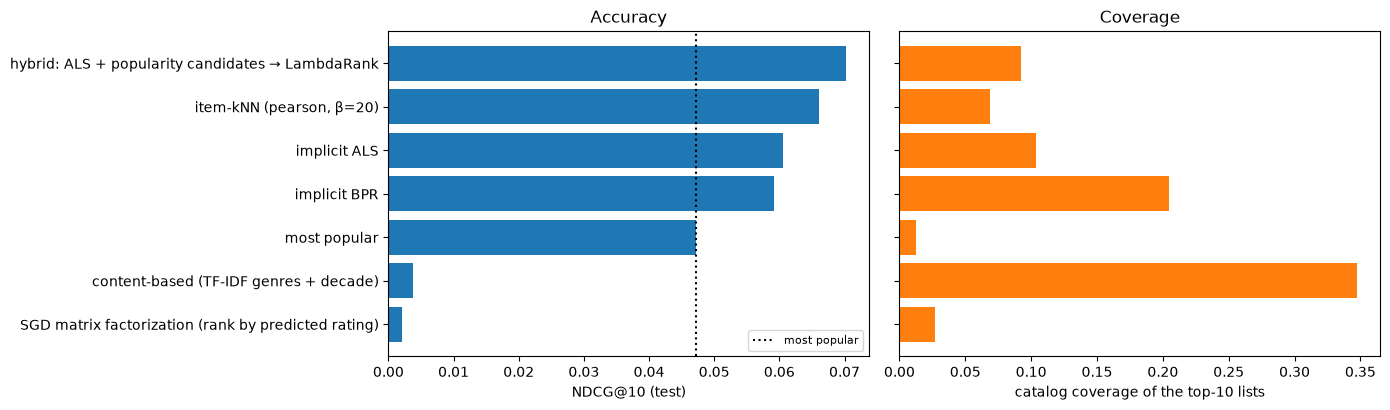

In [46]:
table = pd.DataFrame(results).set_index("model").sort_values("NDCG@k", ascending=False)
show_cols = ["NDCG@k", "recall@k", "MAP@k", "hit rate@k", "coverage", "novelty", "diversity", "fit s"]
print(table[show_cols].round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
names = table.index[::-1]
axes[0].barh(names, table.loc[names, "NDCG@k"], color="#1f77b4")
axes[0].axvline(table.loc["most popular", "NDCG@k"], color="k", ls=":", label="most popular")
axes[0].set(xlabel="NDCG@10 (test)", title="Accuracy")
axes[0].legend(fontsize=8)
axes[1].barh(names, table.loc[names, "coverage"], color="#ff7f0e")
axes[1].set(xlabel="catalog coverage of the top-10 lists", title="Coverage")
plt.tight_layout()
plt.show()

### Step 3 — Two real users: history, recommendations, and what they watched next

In [47]:
counts_full = np.diff(R_train_full.indptr)
typical_user = int(np.argmin(np.abs(counts_full - np.median(counts_full))))
heavy_user = int(np.argmin(np.abs(counts_full - np.quantile(counts_full, 0.9))))
best_model = table.index[0]


def show_user(u, model_name):
    uid = user_ids[u]
    history = train_full[train_full["userId"] == uid].sort_values("timestamp").tail(5)
    print(f"\nuser {uid} — {counts_full[u]} training ratings; the 5 most recent before the test period:")
    for _, row in history.iterrows():
        print(f"   {row['rating']:.1f}★  {titles[i_index[row['movieId']]]}")
    recs_u = test_recs[model_name][u]
    hit_flags = [item in test_truth[u] for item in recs_u]
    print(f"  {model_name} → top-10 ({sum(hit_flags)} of them watched next):")
    for rank, (item, hit) in enumerate(zip(recs_u, hit_flags), start=1):
        print(f"   {rank:2d}. {'✅' if hit else '  '} {titles[item]}")
    print("  actually watched next:", "; ".join(titles[sorted(test_truth[u])]))


show_user(typical_user, best_model)
show_user(heavy_user, best_model)


user 86 — 60 training ratings; the 5 most recent before the test period:
   3.5★  Independence Day (a.k.a. ID4) (1996)
   4.0★  Groundhog Day (1993)
   3.0★  WALL·E (2008)
   4.0★  Forrest Gump (1994)
   4.5★  Ocean's Eleven (2001)
  hybrid: ALS + popularity candidates → LambdaRank → top-10 (1 of them watched next):
    1.    Star Wars: Episode III - Revenge of the Sith (2005)
    2.    Braveheart (1995)
    3. ✅ Monsters, Inc. (2001)
    4.    Lion King, The (1994)
    5.    Pulp Fiction (1994)
    6.    Apollo 13 (1995)
    7.    Speed (1994)
    8.    Die Hard (1988)
    9.    Schindler's List (1993)
   10.    Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)
  actually watched next: Monsters, Inc. (2001); Spy Game (2001); Bruce Almighty (2003); Big Fish (2003); 300 (2007); Coraline (2009); Imaginarium of Doctor Parnassus, The (2009); Cloudy with a Chance of Meatballs (2009); Partly Cloudy (2009); Secret of Kells, The (2009)

user 517 — 390 training rat

### Step 4 — Conclusions (computed)

In [48]:
pop_ndcg = table.loc["most popular", "NDCG@k"]
beats_pop = table.index[table["NDCG@k"] > pop_ndcg].tolist()
mf_name = "SGD matrix factorization (rank by predicted rating)"
print(f"🏆 best NDCG@10: {best_model} = {table.iloc[0]['NDCG@k']:.4f} → {table.iloc[0]['NDCG@k'] / pop_ndcg:.2f}× most popular ({pop_ndcg:.4f})")
print(f"• {len(beats_pop)} of {len(table) - 1} other models beat most-popular on NDCG@10: {beats_pop}")
print(f"• widest catalog coverage: {table['coverage'].idxmax()} ({table['coverage'].max():.1%}); most popular covers {table.loc['most popular', 'coverage']:.1%}")
print(f"• ranking by predicted rating: {mf_name} NDCG@10 {table.loc[mf_name, 'NDCG@k']:.4f} vs implicit ALS {table.loc['implicit ALS', 'NDCG@k']:.4f} "
      f"— {'lower: good rating prediction ≠ good top-10' if table.loc[mf_name, 'NDCG@k'] < table.loc['implicit ALS', 'NDCG@k'] else 'not lower in this run'}")
hybrid_name = "hybrid: ALS + popularity candidates → LambdaRank"
print(f"• the simple LTR hybrid {'beats' if table.loc[hybrid_name, 'NDCG@k'] > table.loc['implicit ALS', 'NDCG@k'] else 'does not beat'} plain ALS "
      f"({table.loc[hybrid_name, 'NDCG@k']:.4f} vs {table.loc['implicit ALS', 'NDCG@k']:.4f}) with 7 features")
fastest_good = table[table["NDCG@k"] >= 0.9 * table.iloc[0]["NDCG@k"]]["fit s"].idxmin()
print(f"• fastest model within 10% of the best NDCG: {fastest_good} ({table.loc[fastest_good, 'fit s']:.2f}s)")
print(f"• absolute numbers are low (recall@10 ≈ {table.iloc[0]['recall@k']:.2f}) because each user's next 10 movies are hard to guess from ~9,700 — compare models, not raw values")

🏆 best NDCG@10: hybrid: ALS + popularity candidates → LambdaRank = 0.0702 → 1.49× most popular (0.0472)
• 4 of 6 other models beat most-popular on NDCG@10: ['hybrid: ALS + popularity candidates → LambdaRank', 'item-kNN (pearson, β=20)', 'implicit ALS', 'implicit BPR']
• widest catalog coverage: content-based (TF-IDF genres + decade) (34.7%); most popular covers 1.3%
• ranking by predicted rating: SGD matrix factorization (rank by predicted rating) NDCG@10 0.0021 vs implicit ALS 0.0605 — lower: good rating prediction ≠ good top-10
• the simple LTR hybrid beats plain ALS (0.0702 vs 0.0605) with 7 features
• fastest model within 10% of the best NDCG: item-kNN (pearson, β=20) (0.42s)
• absolute numbers are low (recall@10 ≈ 0.07) because each user's next 10 movies are hard to guess from ~9,700 — compare models, not raw values


**Stretch goals**
1. Evaluate separately for **light** users (< 50 training ratings) and **heavy** users — which model wins for cold-ish users?
2. Build a **global time cutoff** split (train before 2016-01-01, test after) and check whether the model ranking changes.
3. Tune ALS `iterations` and try `implicit.nearest_neighbours.ItemItemRecommender` / `bm25_weight` confidence weighting; compare with your NumPy item-kNN.
4. Give the LambdaRank hybrid richer features (recency of the user's genres, item age, the user's rating of the most similar watched movie) and check whether its lead over item-kNN and ALS grows — and whether it also holds on the validation users, where the 7-feature version did not beat ALS.

### 🗣️ How to talk about this in an interview
- "I evaluated seven recommenders on MovieLens with a temporal leave-last-10 split — random splits made even popularity look almost twice as good — tuning everything on a separate validation window and scoring the test set once."
- "I reported NDCG@10, recall@10 and MAP@10 alongside catalog coverage, novelty and diversity, and verified my metric code against scikit-learn's `ndcg_score` and hand-computed examples."
- "Every model trained on who-watched-what — item-kNN, ALS, BPR, and a LambdaRank hybrid over ALS and popularity candidates — beat most-popular on NDCG@10, while matrix factorization tuned for rating RMSE ranked last: rating prediction and top-N ranking are different objectives."
- "I built the ALS user update and SGD matrix factorization from scratch and matched `implicit`'s `recalculate_user` exactly, so I can explain the confidence weighting and why ALS parallelizes."
- "Next I'd A/B test the best model against popularity, add exploration for cold-start items, and monitor coverage and exposure concentration for feedback loops."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Explicit vs implicit feedback — how does it change the model and the evaluation?**

<details><summary>Show answer</summary>

- **30-second answer:** Explicit feedback (ratings) has positive and negative signal but is scarce and biased toward chosen items; implicit feedback (clicks, plays, purchases) is abundant but only positive, and "no interaction" is ambiguous. Implicit models treat unobserved items as weak negatives with low confidence (weighted ALS) or learn pairwise preferences (BPR), and are evaluated with ranking metrics on held-out interactions, not RMSE.
- **Go deeper:** Ratings are missing not at random (people rate what they chose). Implicit signals can carry strength (watch fraction, repeat count) that becomes confidence $c_{ui} = 1 + \alpha r_{ui}$. Many products combine both.
- **❌ Common wrong answer:** "Treat every missing cell as a zero rating and run a regression."

</details>

**Q2. Why NDCG@k instead of RMSE to choose a recommender?**

<details><summary>Show answer</summary>

- **30-second answer:** Users see a short ranked list, so what matters is putting relevant items at the top; NDCG discounts hits by position and normalizes by the ideal list. RMSE measures rating prediction on items the user already rated, ignoring which items are shown — in our experiments the lowest-RMSE model ranked poorly.
- **Go deeper:** Also track recall@k (retrieval), MAP, MRR, coverage, novelty, diversity; offline metrics on logged data are biased toward what the old system showed, so confirm with an A/B test.
- **❌ Common wrong answer:** "Lower RMSE always means better recommendations — that's what the Netflix Prize optimized."

</details>

**Q3. User-based vs item-based collaborative filtering — which scales better and why?**

<details><summary>Show answer</summary>

- **30-second answer:** Item-based: item–item similarities are more stable and can be precomputed as top-k neighbour lists, scoring is a sum over the user's short history, and it explains itself ("because you watched X"). User neighbourhoods change with every interaction and there are usually far more users than items.
- **Go deeper:** Use adjusted cosine or Pearson for ratings, shrinkage $\frac{n}{n+\beta}$ for similarities from few co-raters, prune to top-k neighbours; memory is $O(k \cdot I)$ after pruning. On our data Pearson with β=20 was best.
- **❌ Common wrong answer:** "User-based, because users are what we're personalizing for."

</details>

**Q4. Explain matrix factorization with biases and how you train it.**

<details><summary>Show answer</summary>

- **30-second answer:** $\hat r_{ui} = \mu + b_u + b_i + p_u^\top q_i$ with $f$-dimensional user and item vectors; minimize squared error over **observed** ratings plus L2 regularization, via SGD ($e = r - \hat r$; $p_u \mathrel{+}= \eta(e q_i - \lambda p_u)$, etc.) or ALS (alternating closed-form ridge solves). Early-stop on validation RMSE.
- **Go deeper:** Plain SVD needs a full matrix; imputing zeros biases factors (our imputed SVD barely beat the bias model). Biases capture most of the explainable variance; factors capture taste. Koren, Bell & Volinsky (2009) add implicit signals and time dynamics.
- **❌ Common wrong answer:** "Run numpy's SVD on the rating matrix with missing values filled with zeros."

</details>

**Q5. How does ALS for implicit feedback work, and why not SGD?**

<details><summary>Show answer</summary>

- **30-second answer:** Minimize $\sum_{u,i} c_{ui}(p_{ui} - x_u^\top y_i)^2 + \lambda(\lVert X\rVert^2 + \lVert Y\rVert^2)$ over **all** cells, with preference $p_{ui}\in\{0,1\}$ and confidence high for observed items. Fix $Y$: $x_u = (Y^\top Y + Y^\top(C^u - I)Y + \lambda I)^{-1} Y^\top C^u p(u)$; $Y^\top Y$ is shared, so each user costs $O(n_u f^2 + f^3)$ and users solve in parallel; then swap. SGD would have to iterate over billions of zero cells.
- **Go deeper:** `implicit` 0.7 multiplies the stored values by `alpha` and uses them as $c_{ui}$ (we matched `recalculate_user` exactly); the conjugate-gradient variant avoids the $f^3$ solve. Spark MLlib ALS is the distributed version.
- **❌ Common wrong answer:** "ALS is just SGD with a different learning rate."

</details>

**Q6. What does BPR optimize, and when would you prefer it?**

<details><summary>Show answer</summary>

- **30-second answer:** Bayesian Personalized Ranking samples (user, positive item, negative item) triples and maximizes $\ln\sigma(\hat x_{ui} - \hat x_{uj})$ with SGD — a smooth surrogate for per-user AUC, i.e. it directly learns to rank positives above negatives. Prefer it when only relative preferences matter and you can sample good negatives.
- **Go deeper:** Sampling uniform negatives mostly picks easy obscure items; popularity-aware or hard-negative sampling helps. On our validation split, weighted ALS beat BPR; results vary by dataset and tuning.
- **❌ Common wrong answer:** "BPR predicts star ratings with a Bayesian model."

</details>

**Q7. How do you handle cold start for new users and new items?**

<details><summary>Show answer</summary>

- **30-second answer:** New users: popularity (segmented by region/device/time), onboarding questions, session-based models, then CF as interactions accumulate. New items: content/metadata embeddings (content-based or a two-tower item tower on features), plus exploration traffic (bandits) to gather interactions. Report metrics separately for cold and warm segments.
- **Go deeper:** 3.3% of our test interactions were movies absent from training — unreachable for pure CF. Hybrid models that take item features can score them on day one.
- **❌ Common wrong answer:** "Matrix factorization handles new items automatically."

</details>

**Q8. What is a two-tower model and how does it serve recommendations at scale?**

<details><summary>Show answer</summary>

- **30-second answer:** Two neural networks embed the user (history, context) and the item (ID, metadata) into the same space; training pushes the dot product of engaged pairs up versus sampled negatives (often in-batch softmax with sampling-bias correction). Item embeddings are precomputed into an ANN index (FAISS/ScaNN/HNSW); at request time the user tower runs once and ANN retrieves hundreds of candidates for a ranker.
- **Go deeper:** It generalizes matrix factorization (MF = towers that are just ID embeddings) and handles cold-start items through features. YouTube's candidate-generation network (Covington et al. 2016) is the classic example.
- **❌ Common wrong answer:** "Two-tower models score every item with a deep network per request."

</details>

### 💻 Coding

**Q9. Implement NDCG@k for one user.**

<details><summary>Show answer</summary>

- **30-second answer:** `dcg = sum(1/log2(rank+1) for rank, item in enumerate(recs[:k], 1) if item in relevant)`; `idcg = sum(1/log2(r+1) for r in range(1, min(k, len(relevant)) + 1))`; return `dcg/idcg`.
- **Go deeper:** For graded relevance use gain `rel` (scikit-learn) or `2**rel - 1` (common in papers). Vectorize over users with a boolean hit matrix × discount vector. Note IDCG uses min(k, |R|) — Pitfall 5 showed the damage otherwise.
- **❌ Common wrong answer:** Dividing by `log2(rank)` starting at rank 1 (division by zero), or normalizing by an ideal list of length k regardless of |R|.

</details>

**Q10. Score item-based kNN for all users efficiently with sparse matrices.**

<details><summary>Show answer</summary>

- **30-second answer:** With the user–item CSR matrix $R$ (0/1) and a pruned item–item similarity $S$, all scores are one product: `scores = R @ S` (users × items). Mask seen items (`scores[R.nonzero()] = -inf`), then `argpartition` for the top-k per row and sort only those k.
- **Go deeper:** Compute $S$ from `R.T @ R` divided by column norms; prune each column to its top-k with `np.partition(-S, k-1, axis=0)`; for big catalogs keep $S$ sparse and batch users.
- **❌ Common wrong answer:** Nested Python loops over users, items, and neighbours, or a full `argsort` of every row.

</details>

### 🐛 Debugging Scenarios

**Q11. Your new model's offline NDCG is 2× the old one, measured on a random 80/20 split. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** The split: random splits leak each user's future (on MovieLens popularity alone looked 1.9× better on a random split). Re-evaluate with a temporal split, ensure features and popularity counts use only pre-cutoff data, and compare against strong baselines on the same split.
- **Go deeper:** Also check sampled vs full-catalog metrics, whether seen items are filtered consistently, whether both models are evaluated on the same users, and whether duplicate interactions cross the split.
- **❌ Common wrong answer:** "Great — ship it."

</details>

**Q12. Offline NDCG improved, but the A/B test shows no change in watch time. Why might that happen?**

<details><summary>Show answer</summary>

- **30-second answer:** Offline logs only contain items the old system exposed (selection/position bias), so offline gains may reflect agreeing with the old policy; the metric (held-out interactions) may not match the business goal (watch time, retention); and users may have found those items anyway. Check novelty, coverage, and position effects, and run longer tests for delayed effects.
- **Go deeper:** Use counterfactual/off-policy evaluation with logged propensities (IPS), interleaving experiments for sensitivity, and guardrail metrics. Make sure the experiment had enough power.
- **❌ Common wrong answer:** "The A/B test must be broken; offline metrics don't lie."

</details>

**Q13. After upgrading `implicit`, recommendations became nonsense but nothing crashed during training. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Since version 0.5, `fit` expects a **users × items** matrix (older versions took items × users). A swapped matrix trains silently with users and items exchanged. Assert `model.user_factors.shape[0] == n_users` after fitting and pass `user_items[userids]` to `recommend`.
- **Go deeper:** Pin library versions, add a smoke test that a known user's recommendations overlap with a popularity baseline, and read the changelog for API changes (`recommend` also returns arrays of ids and scores now).
- **❌ Common wrong answer:** "ALS is random; retrain with a different seed."

</details>

### 🏗️ Design

**Q14. Design the "Recommended for you" row for a new movie-streaming service.**

<details><summary>Show answer</summary>

- **30-second answer:** Goal and metrics first (watch time / retention online; recall@100 for retrieval, NDCG@10 offline; coverage and diversity guardrails). Day one: popularity + content-based from metadata and onboarding picks. As data grows: candidate generation from item-kNN, implicit ALS or two-tower embeddings with ANN; a GBM/neural ranker with user, item, and context features trained on logged impressions; MMR re-ranking for diversity; exploration slots for new titles. Evaluate with temporal splits, then A/B test; monitor feedback loops.
- **Go deeper:** Serving: precompute candidates daily, rank online within a latency budget, cache per user; log impressions and positions for debiasing. The full system-design walkthrough is in [ML System Design, case study 16](../15_Interview_Prep/03_ML_System_Design.ipynb).
- **❌ Common wrong answer:** "Train one deep model that scores every movie for every request."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** A user has 4 relevant items; your top-5 list contains 2 of them. What are precision@5 and recall@5?
<details><summary>Answer</summary>

**0.4 and 0.5** — 2/5 of the slots are relevant; 2/4 of the relevant items were found.
</details>

**2.** A user has exactly one relevant item and it is ranked **first**. What is NDCG@10?
<details><summary>Answer</summary>

**1.0** — DCG = 1/log₂(2) = 1 equals the ideal DCG for one relevant item.
</details>

**3.** 1,000 users, 10,000 items, 50,000 interactions. What is the density of the user–item matrix?
<details><summary>Answer</summary>

**0.5%** — 50,000 / (1,000 × 10,000) = 0.005.
</details>

**4.** A biased MF model has 64 factors, 1,000,000 users and 100,000 items. How many parameters (factors + user and item biases + the global mean)?
<details><summary>Answer</summary>

**71,500,001** — (1,000,000 + 100,000) × 64 = 70,400,000 factors, + 1,100,000 biases, + 1 global mean.
</details>

**5.** In `implicit` 0.7 you fit `AlternatingLeastSquares(alpha=10)` on a matrix whose entry for (user, movie) is 3. What confidence does the solver use for that cell?
<details><summary>Answer</summary>

**30** — `implicit` multiplies the stored value by `alpha` (the Hu et al. paper's formula $1 + \alpha r$ would give 31); unobserved cells have confidence 1.
</details>

## 📚 Resources

### 📖 Official Docs
- [implicit documentation](https://benfred.github.io/implicit/) — ALS, BPR, LMF and nearest-neighbour recommenders; the users × items API
- [MovieLens | GroupLens](https://grouplens.org/datasets/movielens/) — the datasets (small, 1M, 25M, 32M) and their usage licence
- [scikit-learn — ndcg_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html) — reference NDCG implementation (linear gains, tie handling)
- [LightGBM — LGBMRanker](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRanker.html) — LambdaRank for the ranking stage
- [Google for Developers — Recommendation Systems course](https://developers.google.com/machine-learning/recommendation) · [Matrix factorization](https://developers.google.com/machine-learning/recommendation/collaborative/matrix) — candidate generation, WALS, and two-tower retrieval explained

### 🎥 Videos
- [Stanford (Mining Massive Datasets) — Lecture 43: Collaborative Filtering](https://www.youtube.com/watch?v=h9gpufJFF-0) — Jure Leskovec on user-/item-based CF, similarity, and the utility matrix, like section 7
- [Stanford (Mining Massive Datasets) — Lecture 54: Latent Factor Models](https://www.youtube.com/watch?v=4-f77HjB_CI) — the matrix-factorization view from the Netflix Prize, like section 8
- [Xavier Amatriain — Lecture 1+2 (Machine Learning Summer School 2014)](https://www.youtube.com/watch?v=bLhq63ygoU8) — ~2 hours from Netflix's former head of algorithms: CF, MF, implicit feedback, ranking, and lessons from production
- [DeepLearningAI — Machine Learning Specialization by Andrew Ng](https://www.youtube.com/playlist?list=PLkDaE6sCZn6FNC6YRfRQc_FbeQrF8BwGI) — Course 3, Week 2 covers collaborative filtering and content-based recommenders from scratch

### 📄 Papers
- [Koren, Bell & Volinsky (2009) — Matrix Factorization Techniques for Recommender Systems](https://dl.acm.org/doi/10.1109/MC.2009.263) — IEEE Computer: biases, factors, implicit signals, temporal dynamics
- [Hu, Koren & Volinsky (2008) — Collaborative Filtering for Implicit Feedback Datasets](https://dl.acm.org/doi/10.1109/ICDM.2008.22) — ICDM: preference/confidence weighting and the ALS trick
- [Rendle et al. (2009) — BPR: Bayesian Personalized Ranking from Implicit Feedback](https://arxiv.org/abs/1205.2618) — pairwise ranking loss
- [Covington, Adams & Sargin (2016) — Deep Neural Networks for YouTube Recommendations](https://research.google/pubs/deep-neural-networks-for-youtube-recommendations/) — two-stage candidate generation + ranking in production
- [Krichene & Rendle (2020) — On Sampled Metrics for Item Recommendation](https://research.google/pubs/on-sampled-metrics-for-item-recommendation/) — why sampled metrics mislead (Pitfall 4)
- [Harper & Konstan (2015) — The MovieLens Datasets: History and Context](https://dl.acm.org/doi/10.1145/2827872) — the dataset citation required by the licence

### 📘 Books & Courses
- [Mining of Massive Datasets](http://www.mmds.org/) — free book; chapter 9 covers recommendation systems, and the site links the Stanford lectures above

### 🏋️ Practice
- [GitHub — recommenders-team/recommenders](https://github.com/recommenders-team/recommenders) — Microsoft's best-practice notebooks for ALS, BPR, two-tower, and LightGBM ranking on MovieLens

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| User–item matrix | sparse interactions; explicit ratings or implicit events | `scipy.sparse.csr_matrix((data, (rows, cols)))`; density = nnz / (U·I) |
| Long tail & cold start | few items get most interactions; new users/items have none | popularity fallback, content features, exploration |
| Temporal split | evaluate forward in time, no future leakage | leave-last-N per user or a global time cutoff; validation window for tuning |
| Ranking metrics | quality of the top-k list | P@k, R@k, MAP@k, NDCG@k $=\text{DCG}/\text{IDCG}$ with IDCG over min(k, \|R\|), HR@k, MRR |
| Beyond accuracy | catalog coverage, novelty, diversity | share of catalog shown; mean −log₂(pop); 1 − mean pairwise similarity |
| Baselines | most-popular; $\mu + b_u + b_i$ | regularized biases $b_i = \frac{\sum(r-\mu-b_u)}{\lambda+n_i}$ |
| Content-based | match user profiles to item metadata | `TfidfVectorizer`, profile = Σ (r − r̄_u)·item vector, cosine |
| Item-kNN CF | "people who watched X also watched Y" | $S$ = cosine / adjusted cosine / Pearson + shrinkage, prune top-k, `scores = R @ S` |
| Matrix factorization | latent user/item vectors | $\hat r = \mu + b_u + b_i + p_u^\top q_i$, SGD or ALS, early stopping |
| Implicit ALS | weighted MF with confidence | `AlternatingLeastSquares(factors, regularization, alpha).fit(user_items)`; $x_u=(Y^\top Y+Y^\top(C^u-I)Y+\lambda I)^{-1}Y^\top C^u p(u)$ |
| BPR | pairwise ranking loss | `BayesianPersonalizedRanking`; maximize $\ln\sigma(\hat x_{ui}-\hat x_{uj})$ |
| Two-stage + LTR | candidates → ranker → re-ranker | ANN over embeddings; `lgb.LGBMRanker(objective="lambdarank")` with `group=` |
| Re-ranking | diversity and popularity-bias control | MMR: $\lambda\,\text{rel} - (1-\lambda)\max \text{sim}$; score / pop^β |

## ➡️ What's Next

**[20 · Time Series Forecasting](20_Time_Series_Forecasting.ipynb)** — you just saw how much evaluation depends on respecting time order; forecasting makes time the whole problem: trends, seasonality, ETS/ARIMA, gradient boosting with lag features, and backtesting that never peeks into the future.